#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Fetching

In [2]:
df=pd.read_excel("bioactivity_dataset.xlsx", sheet_name="Sheet1")
df.head(3)

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
0,CHEMBL323869,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active
1,CHEMBL327146,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active
2,CHEMBL116620,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,active


#### Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6629 entries, 0 to 6628
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   molecule_chembl_id  6629 non-null   object 
 1   canonical_smiles    6628 non-null   object 
 2   MW                  6629 non-null   float64
 3   LogP                6629 non-null   float64
 4   NumHDonors          6629 non-null   int64  
 5   NumHAcceptors       6629 non-null   int64  
 6   pIC50               6629 non-null   float64
 7   bioactivity_class   6629 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 414.4+ KB


In [4]:
df.describe(include='all')

c:\BioActivity\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6629,6628,6629.000000,6629.000000,6629.000000,6629.000000,6629.00,6629
unique,5473,5472,NaN,NaN,NaN,NaN,NaN,2
top,CHEMBL98,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,320,320,NaN,NaN,NaN,NaN,NaN,5383
mean,NaN,NaN,419.852171,3.584722,2.881883,5.550913,inf,NaN
std,NaN,NaN,120.481158,1.437887,1.132482,2.430323,NaN,NaN
min,NaN,NaN,75.067000,-14.260700,0.000000,0.000000,2.39,NaN
25%,NaN,NaN,341.411000,2.554200,2.000000,4.000000,6.17,NaN
50%,NaN,NaN,401.511000,3.478400,3.000000,5.000000,6.88,NaN
75%,NaN,NaN,481.560000,4.450500,3.000000,7.000000,7.60,NaN


In [5]:
df['pIC50']=df['pIC50'].replace(['inf', np.inf], np.nan)
df.describe(include='all')

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6629,6628,6629.000000,6629.000000,6629.000000,6629.000000,6627.000000,6629
unique,5473,5472,NaN,NaN,NaN,NaN,NaN,2
top,CHEMBL98,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,320,320,NaN,NaN,NaN,NaN,NaN,5383
mean,NaN,NaN,419.852171,3.584722,2.881883,5.550913,6.752300,NaN
std,NaN,NaN,120.481158,1.437887,1.132482,2.430323,1.286299,NaN
min,NaN,NaN,75.067000,-14.260700,0.000000,0.000000,2.390000,NaN
25%,NaN,NaN,341.411000,2.554200,2.000000,4.000000,6.170000,NaN
50%,NaN,NaN,401.511000,3.478400,3.000000,5.000000,6.880000,NaN
75%,NaN,NaN,481.560000,4.450500,3.000000,7.000000,7.600000,NaN


In [6]:
df.isnull().sum()

molecule_chembl_id    0
canonical_smiles      1
MW                    0
LogP                  0
NumHDonors            0
NumHAcceptors         0
pIC50                 2
bioactivity_class     0
dtype: int64

In [7]:
df.dropna(inplace=True)
df.isnull().sum()

molecule_chembl_id    0
canonical_smiles      0
MW                    0
LogP                  0
NumHDonors            0
NumHAcceptors         0
pIC50                 0
bioactivity_class     0
dtype: int64

In [13]:
import pandas as pd
df_ = pd.DataFrame({'A': [2, 1, 0, 2, 6], 'B': [4, 3, 5, 4, 9]})
print(df_.duplicated())
# Output:
# 0    False
# 1    False
# 2     True
# dtype: bool

print(df_.duplicated().sum())  # Output: 1

0    False
1    False
2    False
3     True
4    False
dtype: bool
1


In [14]:
df_.head(5)

,A,B
0,2,4
1,1,3
2,0,5
3,2,4
4,6,9


In [8]:
df.duplicated().sum()

np.int64(285)

In [9]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop(['molecule_chembl_id'], axis=1, inplace=True)

In [11]:
df.to_excel("bioactivity_dataset_cleaned.xlsx", index=False)

#### Data Analysis

In [12]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [13]:
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50']
Categorical Columns: ['canonical_smiles', 'bioactivity_class']


In [14]:
df[categorical_cols].nunique()

canonical_smiles     5470
bioactivity_class       2
dtype: int64

In [15]:
from rdkit import Chem

invalid_smiles_mask = df['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x) is None)
invalid_smiles = df[invalid_smiles_mask]

print(f"Number of invalid SMILES: {invalid_smiles_mask.sum()}")

Number of invalid SMILES: 0


Text(0.5, 1.0, 'Distribution of Bioactivity Classes')

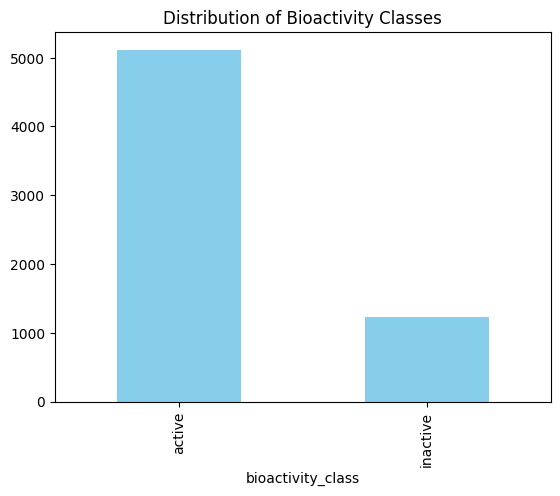

In [16]:
df['bioactivity_class'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Bioactivity Classes')

In [17]:
df.describe(include='all')

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6341,6341.000000,6341.000000,6341.000000,6341.000000,6341.000000,6341
unique,5470,NaN,NaN,NaN,NaN,NaN,2
top,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,247,NaN,NaN,NaN,NaN,NaN,5118
mean,NaN,423.154674,3.607172,2.886296,5.617726,6.739003,NaN
std,NaN,120.324203,1.446058,1.146729,2.446312,1.297159,NaN
min,NaN,75.067000,-14.260700,0.000000,0.000000,2.390000,NaN
25%,NaN,345.786000,2.579300,2.000000,4.000000,6.150000,NaN
50%,NaN,405.477000,3.520340,3.000000,5.000000,6.860000,NaN
75%,NaN,484.603000,4.485520,3.000000,7.000000,7.600000,NaN


#### Feature Transformation

In [4]:
df_cleaned=pd.read_excel("bioactivity_dataset_cleaned.xlsx", sheet_name="Sheet1")
df_cleaned.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,active


In [4]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bioactivity_class'], drop_first=True)
df_cleaned.head(5)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class_inactive
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,False
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,False
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,False
3,O=C(CCCCCCC(=O)Nc1ccccc1)NO,264.325,2.4711,3,3,6.7,False
4,O=C(CCCCCC/C(=N\O)c1ccc(-c2ccccc2)cc1)NO,340.423,4.3779,3,4,8.4,False


Text(0.5, 1.0, 'Distribution of Bioactivity Classes')

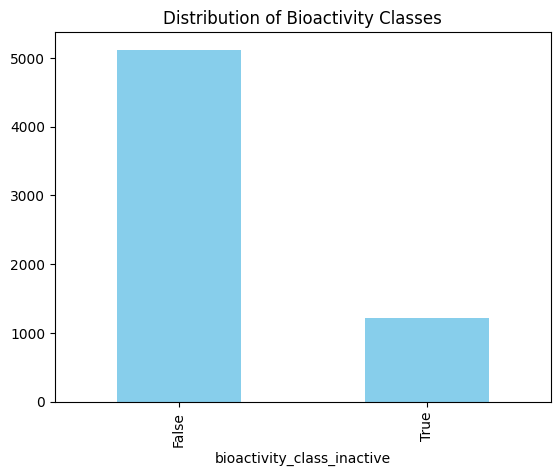

In [5]:
df_cleaned['bioactivity_class_inactive'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Bioactivity Classes')

In [6]:
features_df = df_cleaned.drop(['bioactivity_class_inactive', 'pIC50'], axis=1)
target_df = df_cleaned['bioactivity_class_inactive']

In [7]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6341 entries, 0 to 6340
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   canonical_smiles            6341 non-null   object 
 1   MW                          6341 non-null   float64
 2   LogP                        6341 non-null   float64
 3   NumHDonors                  6341 non-null   int64  
 4   NumHAcceptors               6341 non-null   int64  
 5   pIC50                       6341 non-null   float64
 6   bioactivity_class_inactive  6341 non-null   bool   
dtypes: bool(1), float64(3), int64(2), object(1)
memory usage: 303.6+ KB


In [ ]:
# smiles= features_df['canonical_smiles']

In [8]:
numerical_cols= features_df.select_dtypes(include=[np.number]).columns.tolist()

In [9]:
numerical_cols

['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']

Text(0.5, 1.0, 'Boxplots of Numerical Features')

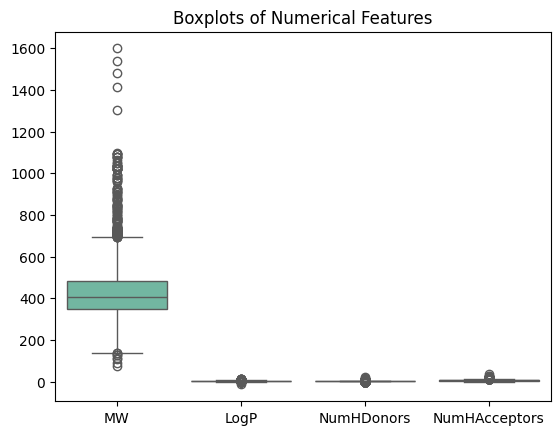

In [10]:
sns.boxplot(data=features_df[numerical_cols], orient='v', palette='Set2')
plt.title('Boxplots of Numerical Features')

In [12]:
# # Calculate Q1 (25th percentile) and Q3 (75th percentile) for each column
# Q1 = features_df[numerical_cols].quantile(0.25)
# Q3 = features_df[numerical_cols].quantile(0.75)

# # Calculate the IQR for each column
# IQR = Q3 - Q1

# # Define the lower and upper bounds for outliers
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# # Identify rows where the data points are outside the bounds
# outliers = ((features_df[numerical_cols] < lower_bound) | (features_df[numerical_cols] > upper_bound)).any(axis=1)

# # Remove outliers from the dataset
# features_df = features_df[~outliers]

# # Check the result
# print(f"Original dataset size: {features_df.shape[0]}")
# print(f"Dataset size after removing outliers: {features_df.shape[0]}")

#features_df=features_df.copy()


Text(0.5, 1.0, 'Boxplots of Numerical Features')

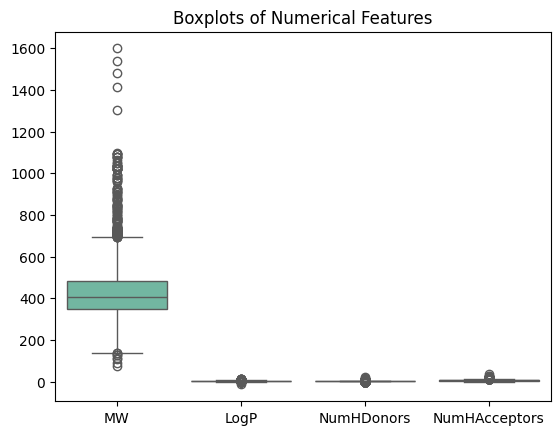

In [11]:

sns.boxplot(data=features_df[numerical_cols], orient='v', palette='Set2')
plt.title('Boxplots of Numerical Features')

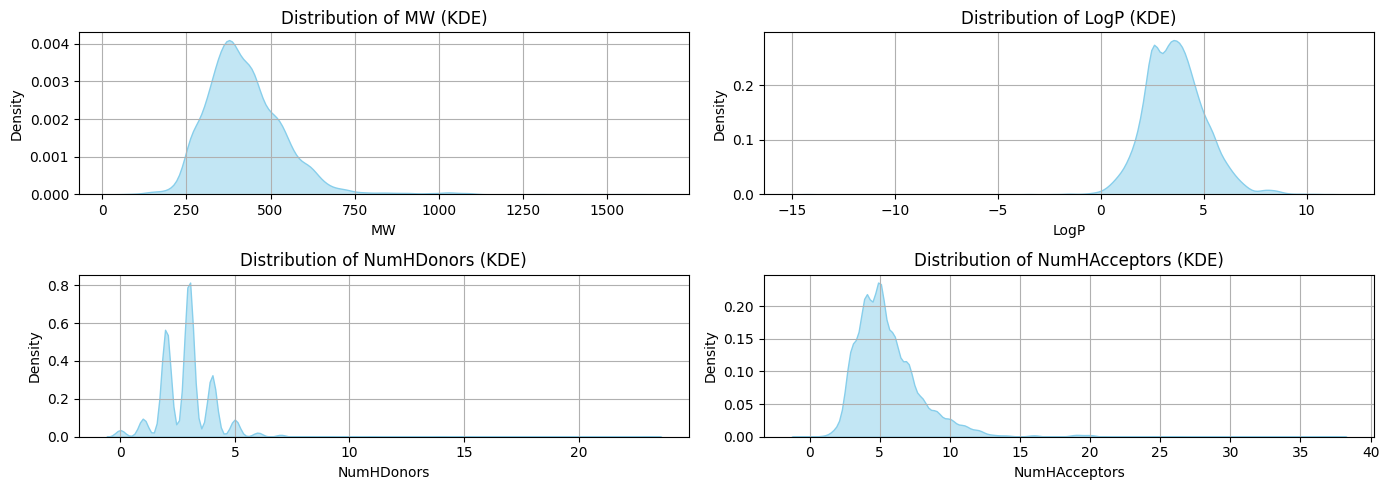

In [12]:

# If there are more than one plot, arrange two plots per row
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].set_title(f'Distribution of {col} (KDE)')
    sns.kdeplot(features_df[col], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
    axes[i].set_ylabel('Density')
    axes[i].grid()
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

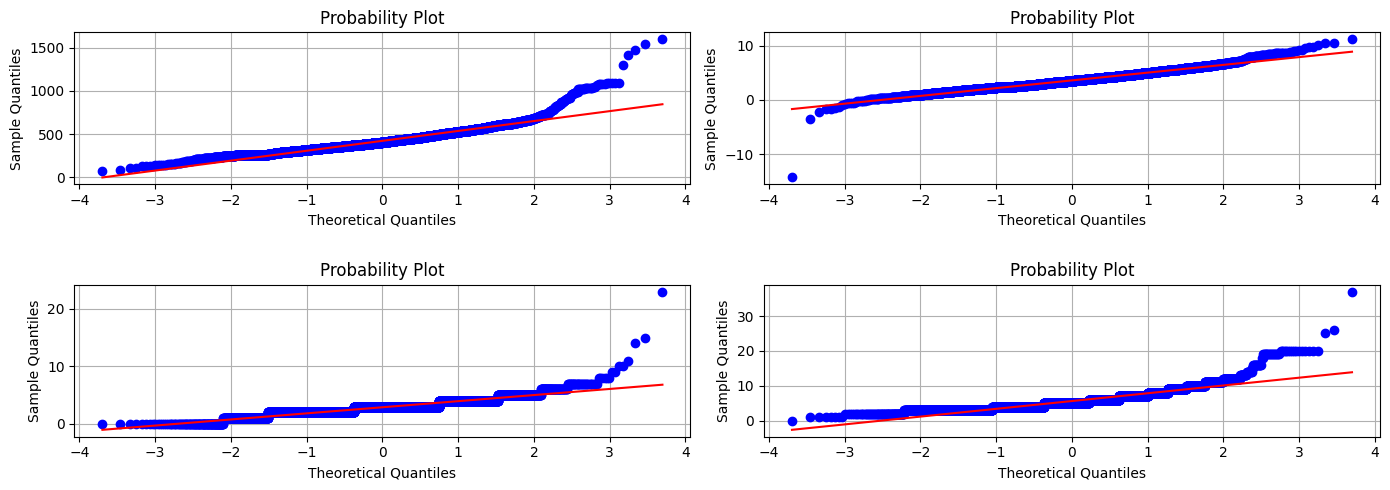

In [13]:
import scipy.stats as stats

fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].set_title(f'Q-Q Plot of {col}')
    stats.probplot(features_df[col], dist="norm", plot=axes[i])
    axes[i].set_xlabel('Theoretical Quantiles')
    # Add gap between rows by increasing vertical space between subplots
    plt.tight_layout(h_pad=2.5)
    axes[i].set_ylabel('Sample Quantiles')
    axes[i].grid()

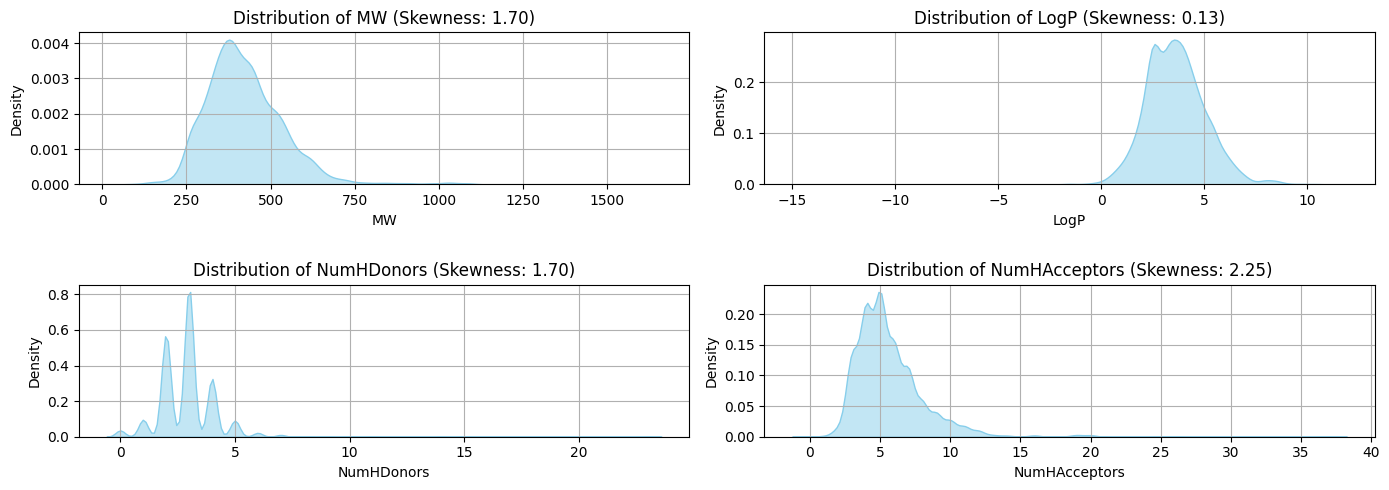

In [18]:
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()
for i, column in enumerate(numerical_cols):
    skewness = stats.skew(features_df[column])  # Calculate skewness
    
    # Plot histogram for visual inspection
    sns.kdeplot(features_df[column], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
    axes[i].set_title(f'Distribution of {column} (Skewness: {skewness:.2f})')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Density')
    axes[i].grid()
    plt.tight_layout(h_pad=2.5)
plt.show()

In [19]:
for column in numerical_cols:
    stat, p_value = stats.normaltest(features_df[column])
    print(f'Normality Test for {column}: Stat={stat:.3f}, p-value={p_value:.3f}')
    if p_value < 0.05:
        print(f'{column} is significantly not normal (p < 0.05)')
    else:
        print(f'{column} is approximately normal (p >= 0.05)')

Normality Test for MW: Stat=2536.683, p-value=0.000
MW is significantly not normal (p < 0.05)
Normality Test for LogP: Stat=663.415, p-value=0.000
LogP is significantly not normal (p < 0.05)
Normality Test for NumHDonors: Stat=3107.232, p-value=0.000
NumHDonors is significantly not normal (p < 0.05)
Normality Test for NumHAcceptors: Stat=3327.011, p-value=0.000
NumHAcceptors is significantly not normal (p < 0.05)


In [20]:
import scipy

features_df['MW']=np.log(features_df['MW']+1)
features_df['NumHDonors']=np.log(features_df['NumHDonors']+1)
features_df['NumHAcceptors']=np.log(features_df['NumHAcceptors']+1)

In [21]:
for column in numerical_cols:
    stat, p_value = stats.normaltest(features_df[column])
    print(f'Normality Test for {column}: Stat={stat:.3f}, p-value={p_value:.3f}')
    if p_value < 0.05:
        print(f'{column} is significantly not normal (p < 0.05)')
    else:
        print(f'{column} is approximately normal (p >= 0.05)')

Normality Test for MW: Stat=240.686, p-value=0.000
MW is significantly not normal (p < 0.05)
Normality Test for LogP: Stat=663.415, p-value=0.000
LogP is significantly not normal (p < 0.05)
Normality Test for NumHDonors: Stat=1549.697, p-value=0.000
NumHDonors is significantly not normal (p < 0.05)
Normality Test for NumHAcceptors: Stat=319.645, p-value=0.000
NumHAcceptors is significantly not normal (p < 0.05)


In [22]:
for col in numerical_cols:
    features_df[col] = (features_df[col] - features_df[col].mean()) / features_df[col].std()
features_df[numerical_cols].head(3)

,MW,LogP,NumHDonors,NumHAcceptors
0,0.483099,0.219236,0.943334,0.344859
1,0.648027,0.570605,0.943334,0.344859
2,0.067137,-0.028334,0.943334,-0.692281


In [23]:
for col in numerical_cols:
    skewness = stats.skew(features_df[col])  # Calculate skewness
    print(f'Skewness of {col}: {skewness:.2f}')
    
    if abs(skewness) > 0.5:
        print(f'{col} is significantly skewed (|Skewness| > 0.5)')
    else:
        print(f'{col} is approximately symmetric (|Skewness| <= 0.5)')

Skewness of MW: 0.03
MW is approximately symmetric (|Skewness| <= 0.5)
Skewness of LogP: 0.13
LogP is approximately symmetric (|Skewness| <= 0.5)
Skewness of NumHDonors: -1.15
NumHDonors is significantly skewed (|Skewness| > 0.5)
Skewness of NumHAcceptors: 0.47
NumHAcceptors is approximately symmetric (|Skewness| <= 0.5)


In [24]:
for column in numerical_cols:
    stat, p_value = stats.normaltest(features_df[column])
    print(f'Normality Test for {column}: Stat={stat:.3f}, p-value={p_value:.3f}')
    if p_value < 0.05:
        print(f'{column} is significantly not normal (p < 0.05)')
    else:
        print(f'{column} is approximately normal (p >= 0.05)')

Normality Test for MW: Stat=240.686, p-value=0.000
MW is significantly not normal (p < 0.05)
Normality Test for LogP: Stat=663.415, p-value=0.000
LogP is significantly not normal (p < 0.05)
Normality Test for NumHDonors: Stat=1549.697, p-value=0.000
NumHDonors is significantly not normal (p < 0.05)
Normality Test for NumHAcceptors: Stat=319.645, p-value=0.000
NumHAcceptors is significantly not normal (p < 0.05)


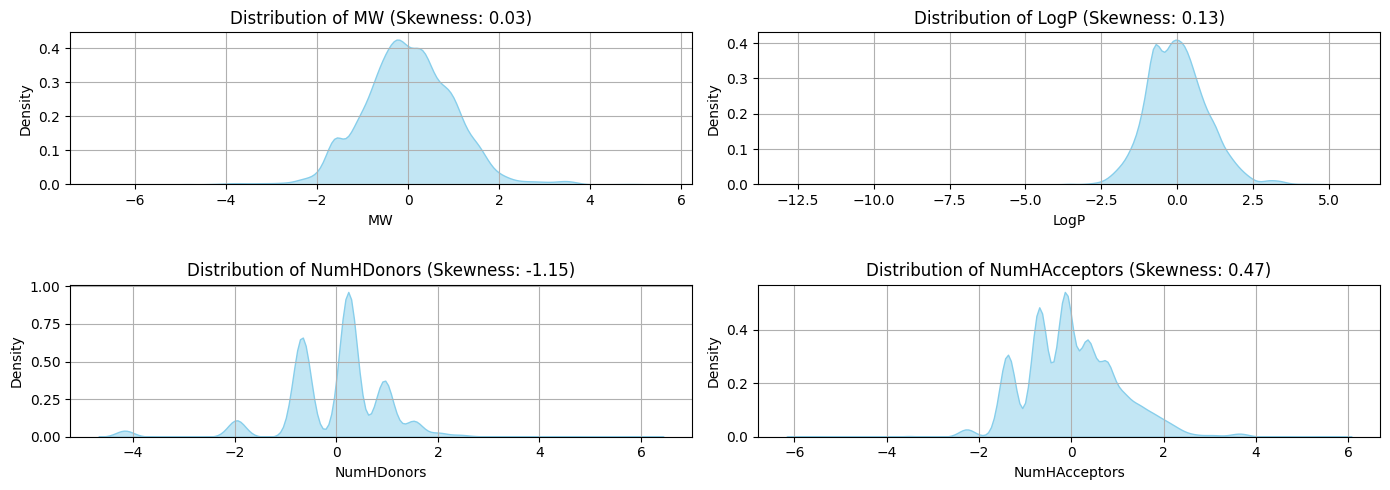

In [25]:
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()
for i, column in enumerate(numerical_cols):
    skewness = stats.skew(features_df[column])  # Calculate skewness
    
    # Plot histogram for visual inspection
    sns.kdeplot(features_df[column], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
    axes[i].set_title(f'Distribution of {column} (Skewness: {skewness:.2f})')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Density')
    axes[i].grid()
    plt.tight_layout(h_pad=2.5)
plt.show()

In [26]:
features_df[numerical_cols].head(3)

,MW,LogP,NumHDonors,NumHAcceptors
0,0.483099,0.219236,0.943334,0.344859
1,0.648027,0.570605,0.943334,0.344859
2,0.067137,-0.028334,0.943334,-0.692281


In [27]:
df_cleaned.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class_inactive
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,False
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,False
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,False


##### RDKit

In [14]:
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit import Chem

features = []

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1000)
    
for idx, row in features_df.iterrows():
    # Convert SMILES to molecule object
    smile= row['canonical_smiles']
    mol = Chem.MolFromSmiles(smile)
    
    if mol:
        # Compute Morgan Fingerprints (ECFP)
        fingerprint = morgan_gen.GetFingerprint(mol)
        fingerprint_array = list(fingerprint)  # Convert to list
        
        # Compute bmolecular descriptors
        # molb_weight = Descriptors.MolWt(mol)  # Molecular Weight
        # logp = Descriptors.MolLogP(mol)  # LogP (Lipophilicity)
        # tpsa = Descriptors.TPSA(mol)  # Topological Polar Surface Area
        
        # Collect features (fingerprint + descriptors)
        features.append(fingerprint_array + [row['MW'], row['LogP'], row['NumHDonors'],
                                                row['NumHAcceptors']])

# Convert the features into a pandas DataFrame
X = pd.DataFrame(features)


##### ChemBERTa

In [49]:
from transformers import BertModel, AutoTokenizer
import torch

# Load pretrained ChemBERTa model (PyTorch version)
model = BertModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

# Encode the SMILES string into embeddings
def get_chemberta_embedding(smiles):
    inputs = tokenizer(smiles, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).detach().numpy()

features_df['chemberta_embedding'] = features_df['canonical_smiles'].apply(get_chemberta_embedding)


You are using a model of type roberta to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.
Some weights of BertModel were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.token_type_embeddings.weight', 'embeddings.word_embeddings.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.attention.output.LayerNorm.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.self.key.bias', 'encoder.layer.0.attention.self.key.weight', 'encoder.layer.0.attention.self.query.bias', 'encoder.layer.0.attention.self.query.weight', 'encoder.layer.0.attention.self.value.bias', 'encoder.layer.0.attention.self.value.weight', 'encoder.layer.0.intermediate.dense.bias', 'encoder.layer.0.

In [50]:
features_df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,chemberta_embedding
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,0.483099,0.219236,0.943334,0.344859,"[[-0.23707804, 0.49395293, 0.24604033, 0.39372..."
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,0.648027,0.570605,0.943334,0.344859,"[[-0.2607426, 0.5720752, 0.30183813, 0.4454808..."
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,0.067137,-0.028334,0.943334,-0.692281,"[[-0.22725658, 0.40469354, 0.2657733, 0.412880..."


In [52]:
features_df['chemberta_embedding'][0].shape

(1, 768)

In [53]:
X=features_df.drop(['canonical_smiles'], axis=1)

In [54]:
X = X.set_index(features_df.index)
y = target_df.loc[features_df.index]

In [57]:
print(X.shape, y.shape)

(6341, 5) (6341,)


In [58]:
X

,MW,LogP,NumHDonors,NumHAcceptors,chemberta_embedding
0,0.483099,0.219236,0.943334,0.344859,"[[-0.23707804, 0.49395293, 0.24604033, 0.39372..."
1,0.648027,0.570605,0.943334,0.344859,"[[-0.2607426, 0.5720752, 0.30183813, 0.4454808..."
2,0.067137,-0.028334,0.943334,-0.692281,"[[-0.22725658, 0.40469354, 0.2657733, 0.412880..."
3,-1.616230,-0.785634,0.234994,-1.380096,"[[0.020684434, 0.4703463, 0.16719496, 0.629871..."
4,-0.674613,0.532985,0.234994,-0.692281,"[[-0.27644372, 0.5241341, 0.23280697, 0.511133..."
...,...,...,...,...,...
6336,-0.556850,-0.909211,0.234994,-0.130294,"[[-0.3302253, 0.6001225, 0.21501105, 0.2417253..."
6337,-1.616230,-0.785634,0.234994,-1.380096,"[[-0.30155748, 0.66687113, 0.18498448, 0.31351..."
6338,-0.023540,0.483125,0.234994,0.756455,"[[-0.23910008, 0.5743231, 0.25488824, 0.486559..."
6339,-1.616230,-0.785634,0.234994,-1.380096,"[[-0.38627326, 0.6163624, 0.15096714, 0.402964..."


In [61]:
first_embedding = np.array(X['chemberta_embedding'].iloc[0])
print(f"Shape of a single embedding: {first_embedding.shape}")

Shape of a single embedding: (1, 768)


In [64]:
def squeeze_embedding(embedding_list):
    """
    Squeezes a pre-pooled embedding of shape (1, d) into shape (d,)
    """
    return np.array(embedding_list).squeeze() # .squeeze() removes dimensions of size 1

# Apply the function to the whole column
X['squeezed_embedding'] = X['chemberta_embedding'].apply(squeeze_embedding)

# 3. Create the final feature set
# Get the traditional features
traditional_features = X[['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']].values

# Stack the squeezed embeddings into a matrix
embedding_matrix = np.vstack(X['squeezed_embedding'].values)

# Combine them by concatenating the columns
final_feature_matrix = np.hstack((traditional_features, embedding_matrix))

print(f"Traditional features shape: {traditional_features.shape}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Final combined feature matrix shape: {final_feature_matrix.shape}")

Traditional features shape: (6341, 4)
Embedding matrix shape: (6341, 768)
Final combined feature matrix shape: (6341, 772)


In [89]:
# Extract the embeddings and convert them into a usable format (e.g., an array)
embeddings = np.array(X['chemberta_embedding'].tolist())
embeddings.shape

(6341, 1, 768)

#### Model Training

##### Data Fecthing

In [2]:
numerical_cols = ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']  

In [3]:
cleaned_df=pd.read_excel("bioactivity_dataset_cleaned_outliers.xlsx")
cleaned_df.head(2)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active,1


In [4]:
features_df = cleaned_df.drop(['bioactivity_class', 'bioactivity','pIC50'], axis=1)
target_df = cleaned_df['bioactivity']

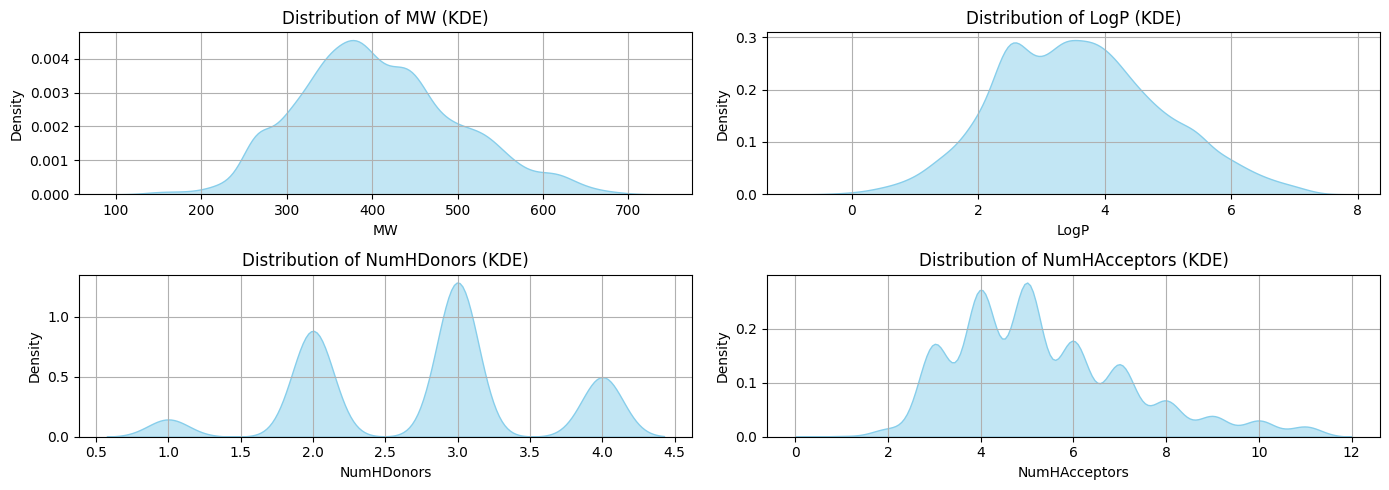

In [5]:
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].set_title(f'Distribution of {col} (KDE)')
    sns.kdeplot(features_df[col], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
    axes[i].set_ylabel('Density')
    axes[i].grid()
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

In [6]:
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit import Chem

features = []

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1000)
    
for idx, row in features_df.iterrows():
    # Convert SMILES to molecule object
    smile= row['canonical_smiles']
    mol = Chem.MolFromSmiles(smile)
    
    if mol:
        # Compute Morgan Fingerprints (ECFP)
        fingerprint = morgan_gen.GetFingerprint(mol)
        fingerprint_array = list(fingerprint)  # Convert to list
        
        # Compute bmolecular descriptors
        # molb_weight = Descriptors.MolWt(mol)  # Molecular Weight
        # logp = Descriptors.MolLogP(mol)  # LogP (Lipophilicity)
        # tpsa = Descriptors.TPSA(mol)  # Topological Polar Surface Area
        
        # Collect features (fingerprint + descriptors)
        features.append(fingerprint_array + [row['MW'], row['LogP'], row['NumHDonors'],
                                                row['NumHAcceptors']])

# Convert the features into a pandas DataFrame
X = pd.DataFrame(features)
X.shape

(5667, 1004)

In [103]:
"""
Molecular Embedding Methods for Drug Discovery
Comparing RDKit fingerprints with modern transformer-based embeddings
"""

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdFingerprintGenerator
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel
import torch

# ============================================================================
# METHOD 2: ChemBERTa (DeepChem/HuggingFace - Best for downstream tasks)
# ============================================================================

def get_chemberta_embeddings(smiles_list, model_name='seyonec/ChemBERTa-zinc-base-v1'):
    """
    State-of-the-art transformer-based embeddings
    Speed: ~50-100 molecules/second (GPU), ~10-20 (CPU)
    Dimension: 768 (base) or 384 (small)
    
    Installation:
        pip install transformers torch
    
    Popular ChemBERTa models:
        - 'seyonec/ChemBERTa-zinc-base-v1' (768d, trained on 77M molecules)
        - 'seyonec/PubChem10M_SMILES_BPE_450k' (768d, PubChem)
        - 'DeepChem/ChemBERTa-77M-MLM' (768d, official DeepChem)
        - 'seyonec/ChemBERTa-zinc-base-v1-finetuned' (task-specific)
    """

    
    # Load model and tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    
    # Move to GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    
    embeddings = []
    batch_size = 32  # Adjust based on GPU memory
    
    for i in tqdm(range(0, len(smiles_list), batch_size), desc="ChemBERTa"):
        batch_smiles = smiles_list[i:i+batch_size]
        
        # Tokenize
        encoded = tokenizer(batch_smiles, 
                           padding=True, 
                           truncation=True, 
                           max_length=512,
                           return_tensors='pt')
        
        encoded = {k: v.to(device) for k, v in encoded.items()}
        
        # Get embeddings
        with torch.no_grad():
            outputs = model(**encoded)
            # Use [CLS] token embedding (first token)
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        
        embeddings.append(batch_embeddings)
    
    return np.vstack(embeddings)

In [8]:
def get_molformer_embeddings(smiles_list):
    """
    IBM's MoLFormer - excellent for property prediction
    Speed: ~30-50 molecules/second (GPU)
    Dimension: 768
    
    Installation:
        pip install transformers torch
    
    Model: 'ibm/MoLFormer-XL-both-10pct'
    """
    
    model_name = 'ibm/MoLFormer-XL-both-10pct'
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    
    embeddings = []
    batch_size = 16
    
    for i in tqdm(range(0, len(smiles_list), batch_size), desc="MoLFormer"):
        batch_smiles = smiles_list[i:i+batch_size]
        
        encoded = tokenizer(batch_smiles, 
                           padding=True, 
                           truncation=True,
                           return_tensors='pt')
        
        encoded = {k: v.to(device) for k, v in encoded.items()}
        
        with torch.no_grad():
            outputs = model(**encoded)
            batch_embeddings = outputs.pooler_output.cpu().numpy()
        
        embeddings.append(batch_embeddings)
    
    return np.vstack(embeddings)


In [9]:
# ============================================================================
# METHOD 4: ChemGPT (Generative model - Good for novelty)
# ============================================================================

def get_chemgpt_embeddings(smiles_list):
    """
    GPT-style model for molecules
    Speed: ~20-40 molecules/second (GPU)
    Dimension: 768
    
    Model: 'ncfrey/ChemGPT-1.2B' or 'ncfrey/ChemGPT-4.7M'
    """
    from transformers import AutoTokenizer, AutoModelForCausalLM
    import torch
    
    model_name = 'ncfrey/ChemGPT-19M'  # Smaller, faster variant
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(model_name)

    if tokenizer.pad_token is None:
        tokenizer.add_special_tokens({'pad_token': '[PAD]'})
        model.resize_token_embeddings(len(tokenizer))
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    
    embeddings = []
    batch_size = 16
    
    for i in tqdm(range(0, len(smiles_list), batch_size), desc="ChemGPT"):
        batch_smiles = smiles_list[i:i+batch_size]
        
        encoded = tokenizer(batch_smiles, 
                           padding=True, 
                           truncation=True,
                           max_length=512,
                           return_tensors='pt')
        
        encoded = {k: v.to(device) for k, v in encoded.items()}
        
        with torch.no_grad():
            outputs = model(**encoded, output_hidden_states=True)
            # Use mean of last hidden state (excluding padding)
            hidden_states = outputs.hidden_states[-1]
            
            # Create attention mask to ignore padding tokens
            attention_mask = encoded['attention_mask'].unsqueeze(-1)
            masked_hidden = hidden_states * attention_mask
            sum_hidden = masked_hidden.sum(dim=1)
            sum_mask = attention_mask.sum(dim=1)
            batch_embeddings = (sum_hidden / sum_mask).cpu().numpy()
        
        embeddings.append(batch_embeddings)
    
    return np.vstack(embeddings)


In [10]:
# ============================================================================
# METHOD 5: Graph Neural Network (GCN/GAT) - Best for structure
# ============================================================================

def get_gnn_embeddings(smiles_list):
    """
    Graph Neural Network embeddings using DeepChem
    Speed: ~100-200 molecules/second
    Dimension: 512 (configurable)
    
    Installation:
        pip install deepchem
    """
    import deepchem as dc
    from deepchem.feat import MolGraphConvFeaturizer
    
    featurizer = MolGraphConvFeaturizer(use_edges=True)
    
    # Convert SMILES to graphs
    features = featurizer.featurize(smiles_list)
    
    # Load pre-trained GCN model (or train your own)
    # This is a placeholder - you'd typically use a pre-trained model
    # For now, we'll use graph features directly
    
    embeddings = []
    for feat in tqdm(features, desc="GNN Features"):
        if feat is not None:
            # Extract node features (averaged)
            node_features = feat.node_features
            embedding = np.mean(node_features, axis=0)
            embeddings.append(embedding)
        else:
            embeddings.append(np.zeros(30))  # Default dimension
    
    return np.array(embeddings)


In [121]:
# ============================================================================
# COMBINED APPROACH: Multi-level Embeddings (RECOMMENDED)
# ============================================================================

def get_hybrid_embeddings(smiles_list, descriptors_df=None, method='chemberta'):
    """
    Hybrid approach: Combine transformer embeddings with RDKit descriptors
    This often gives the best performance!
    
    Args:
        method: 'chemberta', 'molformer', 'chemgpt', or 'rdkit'
    """
    print(f"Generating {method.upper()} embeddings...")
    
    # Get transformer embeddings
    if method == 'chemberta':
        transformer_emb = get_chemberta_embeddings(smiles_list)
    elif method == 'molformer':
        transformer_emb = get_molformer_embeddings(smiles_list)
    elif method == 'chemgpt':
        transformer_emb = get_chemgpt_embeddings(smiles_list)
    else:  # rdkit
        return get_rdkit_embeddings(smiles_list, descriptors_df)
    
    # Add RDKit descriptors for additional chemical information
    print("Adding RDKit descriptors...")
    rdkit_descriptors = []
    
    for smile in tqdm(smiles_list, desc="RDKit descriptors"):
        mol = Chem.MolFromSmiles(smile)
        if mol:
            desc = [
                Descriptors.MolWt(mol),
                Descriptors.MolLogP(mol),
                Descriptors.TPSA(mol),
                Descriptors.NumHDonors(mol),
                Descriptors.NumHAcceptors(mol),
                Descriptors.NumRotatableBonds(mol),
                Descriptors.NumAromaticRings(mol),
                Descriptors.FractionCSP3(mol)
            ]
        else:
            desc = [0] * 8
        rdkit_descriptors.append(desc)
    
    rdkit_descriptors = np.array(rdkit_descriptors)
    
    # Combine embeddings
    combined = np.hstack([transformer_emb, rdkit_descriptors])
    
    print(f"Final embedding shape: {combined.shape}")
    return combined

In [ ]:
print("Generating molecular embeddings...")
    
smiles_list = features_df['canonical_smiles'].tolist()

# OPTION 1: Keep RDKit (fast, good baseline)
# features = get_rdkit_embeddings(smiles_list, features_df)

# OPTION 2: Use ChemBERTa (better accuracy)
#features = get_chemberta_embeddings(smiles_list)
#features = get_molformer_embeddings(smiles_list)
#features = get_chemgpt_embeddings(smiles_list)
#features = get_gnn_embeddings(smiles_list)
#features = get_mol2vec_embeddings(smiles_list)
#features = get_hybrid_embeddings(smiles_list, descriptors_df=None, method='molformer')

#descriptors = features_df[numerical_cols].values

#final_feature_matrix = np.hstack([features, descriptors])

# # Convert to DataFrame
#X = pd.DataFrame(final_feature_matrix)

X = pd.DataFrame(features)

print(f"Feature matrix shape: {X.shape}")

Generating molecular embeddings...
Generating MOLFORMER embeddings...


MoLFormer: 100%|██████████| 355/355 [00:10<00:00, 33.48it/s]


Adding RDKit descriptors...


RDKit descriptors: 100%|██████████| 5667/5667 [00:04<00:00, 1259.39it/s]

Final embedding shape: (5667, 776)
Feature matrix shape: (5667, 776)


In [123]:
X

,0,1,2,3,4,5,6,7,8,9,...,766,767,768,769,770,771,772,773,774,775
0,0.306087,0.610856,0.684239,0.626567,-0.311302,-0.240115,-0.101137,0.556899,0.025337,-0.552039,...,-0.499815,-0.162775,464.522,3.9242,129.65,4.0,6.0,11.0,3.0,0.280000
1,0.143865,0.401925,0.517819,0.106469,-0.469808,-0.178544,-0.352662,0.129285,0.572385,-0.562660,...,-0.022497,0.354613,485.544,4.4323,133.31,4.0,6.0,10.0,4.0,0.222222
2,0.368236,0.378677,0.852213,0.112597,-0.706433,-0.284196,-0.163098,0.124215,-0.047697,-0.584986,...,-0.297427,-0.120041,415.449,3.5662,107.53,4.0,4.0,7.0,3.0,0.041667
3,0.881702,0.626251,0.637252,0.215664,-0.490619,0.030170,0.183831,0.513900,0.442210,-0.569574,...,-0.416035,-0.126673,264.325,2.4711,78.43,3.0,3.0,8.0,1.0,0.428571
4,0.478610,0.634211,0.875304,0.409119,-0.119636,-0.191097,0.189289,0.070985,-0.054656,-0.918291,...,-0.314157,-0.210366,340.423,4.3779,81.92,3.0,4.0,9.0,2.0,0.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5662,0.748029,0.242195,0.800488,0.106843,-0.113632,-0.593151,0.452101,0.194524,-0.100024,0.119367,...,0.068911,0.204254,428.510,4.1652,118.89,5.0,6.0,9.0,3.0,0.272727
5663,0.582605,0.306954,0.829320,0.039977,-0.414374,-0.222087,0.275868,-0.401603,0.102302,-0.216857,...,-0.133969,-0.214270,540.982,6.9305,96.37,3.0,6.0,8.0,5.0,0.033333
5664,-0.038079,-0.003225,0.280945,-0.281226,-0.448621,-0.072120,0.366846,-0.176596,0.114290,-0.271468,...,-0.678833,-0.007779,479.537,3.0017,118.07,3.0,9.0,10.0,3.0,0.320000
5665,0.489442,0.122240,1.313484,-0.078880,0.190807,-0.199635,-0.009984,-0.076292,-0.327286,0.051001,...,-0.338299,0.190945,364.361,2.6632,105.60,3.0,7.0,4.0,3.0,0.105263


In [124]:
len(features_df), len(target_df)

(5667, 5667)

In [125]:
X = X.set_index(features_df.index)
y = target_df.loc[features_df.index]

In [126]:
X.head(3)

,0,1,2,3,4,5,6,7,8,9,...,766,767,768,769,770,771,772,773,774,775
0,0.306087,0.610856,0.684239,0.626567,-0.311302,-0.240115,-0.101137,0.556899,0.025337,-0.552039,...,-0.499815,-0.162775,464.522,3.9242,129.65,4.0,6.0,11.0,3.0,0.280000
1,0.143865,0.401925,0.517819,0.106469,-0.469808,-0.178544,-0.352662,0.129285,0.572385,-0.562660,...,-0.022497,0.354613,485.544,4.4323,133.31,4.0,6.0,10.0,4.0,0.222222
2,0.368236,0.378677,0.852213,0.112597,-0.706433,-0.284196,-0.163098,0.124215,-0.047697,-0.584986,...,-0.297427,-0.120041,415.449,3.5662,107.53,4.0,4.0,7.0,3.0,0.041667


##### Train Test Split

In [127]:

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import StandardScaler

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
#X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

# Feature scaling (needed for some base estimators)
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_val = scaler.transform(X_val)
# X_test = scaler.transform(X_test)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)



(4533, 776) (4533,)
(567, 776) (567,)
(567, 776) (567,)


In [128]:
print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

bioactivity
1    3712
0     821
Name: count, dtype: int64
bioactivity
1    454
0    113
Name: count, dtype: int64
bioactivity
1    475
0     92
Name: count, dtype: int64


In [129]:
y_train.value_counts()

bioactivity
1    3712
0     821
Name: count, dtype: int64

##### Statistical Testing

In [165]:
from scipy.stats import ttest_ind

print("Performing t-test for descriptor significance...")
p_values = {}
for col in numerical_cols:
    group0 = stat_x_train[y_train == 0][col]
    group1 = stat_x_train[y_train == 1][col]
    t_stat, p_val = ttest_ind(group0, group1, nan_policy='omit')
    p_values[col] = p_val
    mean0 = group0.mean()
    mean1 = group1.mean()
    print(f"{col}: Inactive mean = {mean0:.2f}, Active mean = {mean1:.2f}, t-stat = {t_stat}, p-value = {p_val:.50f}")
significant_features = [col for col, p_val in p_values.items() if p_val < 0.05]
print("Significant descriptors (p < 0.05):", significant_features)

Performing t-test for descriptor significance...
MW: Inactive mean = 384.06, Active mean = 412.27, t-stat = -7.929430306884161, p-value = 0.00000000000000275145131835954474550281135104262090
LogP: Inactive mean = 3.32, Active mean = 3.65, t-stat = -6.585409091955932, p-value = 0.00000000005052847655803682222579238952619984630993
NumHDonors: Inactive mean = 2.40, Active mean = 2.84, t-stat = -14.674640494949276, p-value = 0.00000000000000000000000000000000000000000000001146
NumHAcceptors: Inactive mean = 4.98, Active mean = 5.43, t-stat = -6.258437968457921, p-value = 0.00000000042480063954437979746893145997777008204821
Significant descriptors (p < 0.05): ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']


In [166]:
y_train[y_train==0].value_counts().sum()/y_train.value_counts().sum()

np.float64(0.18111625854842267)

Generating t-SNE visualization...


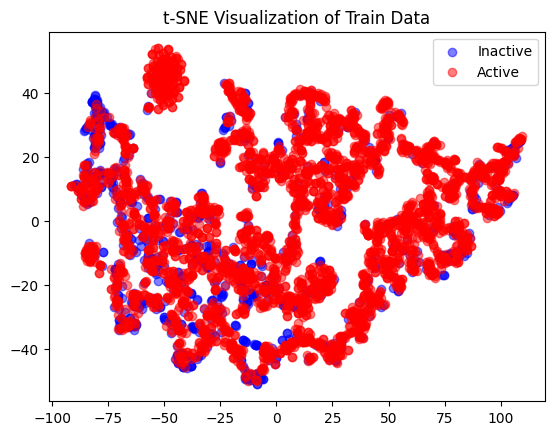

In [23]:
from sklearn.manifold import TSNE
print("Generating t-SNE visualization...")
# Use all features (embeddings + descriptors) for visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_train)
plt.scatter(X_tsne[y_train == 0, 0], X_tsne[y_train == 0, 1], label="Inactive", alpha=0.5, c='blue')
plt.scatter(X_tsne[y_train == 1, 0], X_tsne[y_train == 1, 1], label="Active", alpha=0.5, c='red')
plt.legend()
plt.title("t-SNE Visualization of Train Data")
plt.show()

e:\ML\BioActivity\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


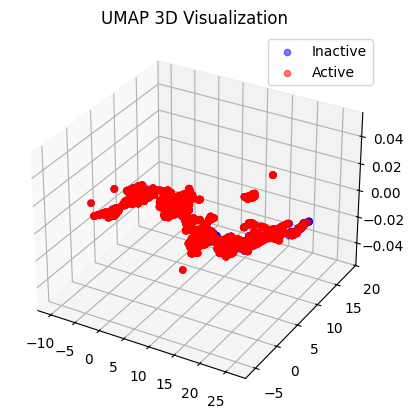

In [24]:
from umap.umap_ import UMAP
umap_model = UMAP(n_components=2, n_neighbors=7, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_train)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_umap[y_train == 0, 0], X_umap[y_train == 0, 1],  c='blue', label="Inactive", alpha=0.5)
ax.scatter(X_umap[y_train == 1, 0], X_umap[y_train == 1, 1], c='red', label="Active", alpha=0.5)
ax.legend()
plt.title("UMAP 3D Visualization")
plt.show()

##### Utilities

In [25]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    average_precision_score
)


def calc_metrics(final_model):
    y_prob = final_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class
    y_pred = final_model.predict(X_test)  # Binary predictions (threshold at 0.5)

    # Step 2: Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)  # This is also Sensitivity
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    mcc = matthews_corrcoef(y_test, y_pred)
    auprc = average_precision_score(y_test, y_prob)  # Area Under Precision-Recall Curve

    # For Specificity: Derive from confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = recall  # Same as recall

    # Step 3: Print or store results (e.g., to fill your table)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Balanced Acc.: {balanced_acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"MCC: {mcc:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"AUPRC: {auprc:.4f}")

In [26]:
from sklearn.metrics import log_loss
import numpy as np
import torch
import torch.nn as nn

# Focal Loss for Imbalanced Data (Test Set)

# Focal Loss implementation (binary classification)
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = nn.BCEWithLogitsLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()
        
def calc_loss(final_model):
    # Calculate log loss
    log_loss_value = log_loss(y_test, final_model.predict_proba(X_test))
    print("Log Loss(Test):", log_loss_value)

    log_loss_value = log_loss(y_train, final_model.predict_proba(X_train))
    print("Log Loss(Train):", log_loss_value)


    # Get predicted probabilities for the positive class
    y_proba = final_model.predict_proba(X_test)[:, 1]
    # Convert to logits (inverse of sigmoid)
    eps = 1e-8  # to avoid log(0)
    logits = np.log(y_proba / (1 - y_proba + eps) + eps)

    # Convert to torch tensors
    logits_tensor = torch.tensor(logits, dtype=torch.float32)
    targets_tensor = torch.tensor(y_test.values, dtype=torch.float32)

    # Calculate focal loss
    focal_loss_fn = FocalLoss(alpha=0.25, gamma=2.0)
    focal_loss_value = focal_loss_fn(logits_tensor, targets_tensor)
    print(f'Focal Loss (Test Set): {focal_loss_value.item():.4f}')

In [27]:
def plot_confusion_matrix(final_model):
    y_pred = final_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [28]:
from pathlib import Path
import joblib
import json

Path("saved_model/ml_models/ChemBERTa-zinc-base-v1").mkdir(parents=True, exist_ok=True)

def save_model(final_model, best_params, model_name):
    # Save the trained model (with compression)
    joblib.dump(final_model, f"saved_model/ml_models/ChemBERTa-zinc-base-v1/{model_name}.pkl", compress=3)

    # Save simple metadata (e.g., columns and best params) for reproducibility
    metadata = {
        "model_type": type(final_model).__name__,
        "best_params": best_params if 'best_params' in globals() else None
    }
    with open(f"saved_model/ml_models/ChemBERTa-zinc-base-v1/{model_name}_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print("Model and metadata saved to saved_model/ml_models/ChemBERTa-zinc-base-v1/")

In [29]:
def shap_plot(final_model):
    import shap

    # Create a SHAP explainer
    #explainer = shap.TreeExplainer(final_model, X_train)
    explainer = shap.Explainer(final_model, X_train)

    # Calculate SHAP values for the test set
    shap_values = explainer.shap_values(X_test)

    # Plot summary plot
    #shap.summary_plot(shap_values, X_test, plot_type="bar")

    #emb_idx = slice(0, 1000)  # e.g., 0:1000
    #desc_idx = slice(1000, 1004)

    #print("Desc Index: " ,desc_idx)

    #explainer = shap.TreeExplainer(final_model)
    #shap_values = explainer.shap_values(X_test)  # Shape: [n_samples, n_features]

    # Overall importance
    #mean_abs_shap = np.abs(shap_values).mean(0)
    #print("Embedding total importance:", mean_abs_shap[emb_idx].sum())
    #print("Descriptors importance:", mean_abs_shap[desc_idx])

    plt.figure(figsize=(8,8))
    shap.summary_plot(shap_values, X_test)  # Clean plot!



In [30]:
from lime.lime_tabular import LimeTabularExplainer

def lime_plot(final_model):
    def predict_proba_wrapper(X):
        return final_model.predict_proba(X)

    explainer = LimeTabularExplainer(
        X_train, 
        class_names=["0", "1"], 
        mode="classification"
    )


    exp = explainer.explain_instance(
        X_test[0], 
        predict_proba_wrapper,
        num_features=10
    )

    # OPTION 2: Show as matplotlib figure
    fig = exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

    # OPTION 3: Print as text
    print("\nFeature contributions:")
    print(exp.as_list())

    # OPTION 4: Get as dictionary
    print("\nExplanation as dict:")
    print(exp.as_map())


##### XGBoost

In [142]:
import optuna
import warnings
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

warnings.filterwarnings("ignore")


neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1\n")


# def objective(trial):
#     param = {
#         "objective": "binary:logistic",
#         "eval_metric": "auc",
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
#         "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "gamma": trial.suggest_float("gamma", 0, 5),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-2, 10.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
#         "scale_pos_weight": trial.suggest_float("scale_pos_weight", scale_pos_weight * 0.5, scale_pos_weight * 1.5),
#         "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "n_jobs": -1
        
#     }
#     # model = xgb.XGBClassifier(**param)
#     # model.fit(X_train, y_train)
#     # pred_prob = model.predict_proba(X_val)[:, 1]
#     # auc = roc_auc_score(y_val, pred_prob)
#     # return 1.0 - auc  # Optuna minimizes, so invert accuracy

#     if param["booster"] == "gblinear":
#         param.pop("max_depth", None)
#         param.pop("min_child_weight", None)
#         param.pop("subsample", None)
#         param.pop("colsample_bytree", None)
#     elif param["booster"] == "dart":
#         param["rate_drop"] = trial.suggest_float("rate_drop", 1e-3, 0.2, log=True)
#         param["skip_drop"] = trial.suggest_float("skip_drop", 1e-3, 0.2, log=True)
    
#     # Convert to DMatrix for XGBoost
#     dtrain = xgb.DMatrix(X_train, label=y_train)
#     dval = xgb.DMatrix(X_val, label=y_val)
    
#     # Train model with early stopping
#     model = xgb.train(
#         param,
#         dtrain,
#         evals=[(dval, "validation")],
#         early_stopping_rounds=10,
#         num_boost_round=param["n_estimators"],
#         verbose_eval=False
#     )
    
#     # Predict probabilities for AUC
#     preds_proba = model.predict(dval)
#     auc = roc_auc_score(y_val, preds_proba)
    
#     return 1.0 - auc  # Optuna minimizes, so invert AUC

# study = optuna.create_study()
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# print("Best trial:")
# print(study.best_trial)
# print("Best params:", study.best_params)

# # Train final model with best params
# best_params = study.best_params
# best_params.update({"objective": "binary:logistic", "eval_metric": "auc", "use_label_encoder": False})
final_model_xgb = xgb.XGBClassifier(scale_pos_weight= scale_pos_weight,
                                   objective='binary:logistic',
                                   eval_metric='auc',
                                   n_jobs=-1)
final_model_xgb.fit(X_train, y_train)
y_pred = final_model_xgb.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Class imbalance ratio: 0.22:1

Final Accuracy: 0.9188712522045855
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.65      0.72        92
           1       0.94      0.97      0.95       475

    accuracy                           0.92       567
   macro avg       0.87      0.81      0.84       567
weighted avg       0.91      0.92      0.92       567



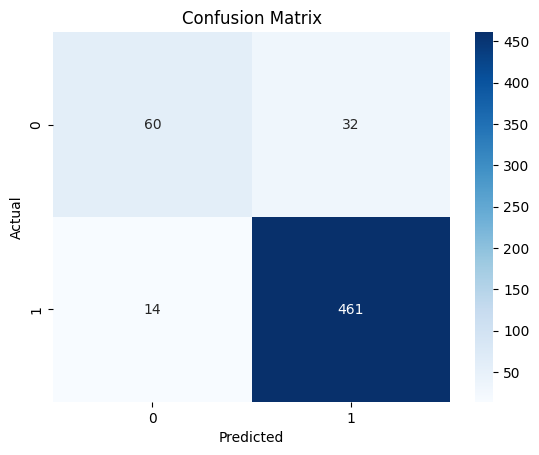

In [143]:
plot_confusion_matrix(final_model_xgb)

In [144]:
calc_metrics(final_model_xgb)

Accuracy: 0.9189
Balanced Acc.: 0.8114
Precision: 0.9351
Recall: 0.9705
F1 Score: 0.9525
ROC-AUC: 0.9343
MCC: 0.6815
Specificity: 0.6522
Sensitivity: 0.9705
AUPRC: 0.9845


In [39]:
calc_loss(final_model_xgb)

Log Loss(Test): 0.2891571422721287
Log Loss(Train): 0.17227966933060118
Focal Loss (Test Set): 0.0235


In [35]:
save_model(final_model_xgb, best_params, "xgboost_bioactivity_model")

Model and metadata saved to saved_model/ml_models/ChemBERTa-zinc-base-v1/


In [37]:
plt.figure(figsize=(5, 3)) 
#shap_plot(final_model_xgb)

<Figure size 500x300 with 0 Axes>

<Figure size 500x300 with 0 Axes>

In [38]:
lime_plot(final_model_xgb)

KeyError: (slice(None, None, None), 0)

##### RandomForest

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def objective(trial):

    
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None, 0.5, 1]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample", None]),
        "random_state": 42
    }
   
    model = RandomForestClassifier(**param, n_jobs=-1)
    model.fit(X_train, y_train)

    # Evaluate on the validation set and compute ROC AUC using the positive-class probabilities
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)
    return 1.0 - auc  # Optuna minimizes, so invert AUC

study = optuna.create_study()
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)

# Train final model with best params
best_params = study.best_params
final_model_rf = RandomForestClassifier(**best_params, n_jobs=-1)
final_model_rf.fit(X_train, y_train)
y_pred = final_model_rf.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

[I 2025-10-26 21:53:43,523] A new study created in memory with name: no-name-2d7afea6-0a93-4d39-84dc-d76347beae0d
[I 2025-10-26 21:53:44,294] Trial 0 finished with value: 0.11553155822385097 and parameters: {'n_estimators': 375, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_samples': 0.9599541961990228, 'criterion': 'gini', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.11553155822385097.
[I 2025-10-26 21:53:46,071] Trial 1 finished with value: 0.09416786869907601 and parameters: {'n_estimators': 489, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_samples': 0.9552293056782922, 'criterion': 'entropy', 'class_weight': None}. Best is trial 1 with value: 0.09416786869907601.
[I 2025-10-26 21:53:46,701] Trial 2 finished with value: 0.09906046547892877 and parameters: {'n_estimators': 313, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 1, 'max_samples': 0

Best trial:
FrozenTrial(number=49, state=1, values=[0.0766246929944252], datetime_start=datetime.datetime(2025, 10, 26, 22, 0, 0, 156971), datetime_complete=datetime.datetime(2025, 10, 26, 22, 0, 1, 555344), params={'n_estimators': 321, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_samples': 0.8554653520023604, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=500, log=False, low=50, step=1), 'max_depth': IntDistribution(high=20, log=False, low=3, step=1), 'min_samples_split': IntDistribution(high=10, log=False, low=2, step=1), 'min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1), 'max_features': CategoricalDistribution(choices=('sqrt', 'log2', None, 0.5, 1)), 'max_samples': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'criterion': CategoricalDistribution(choices=('gini', 'entropy')), 'cl

Text(95.72222222222221, 0.5, 'Actual')

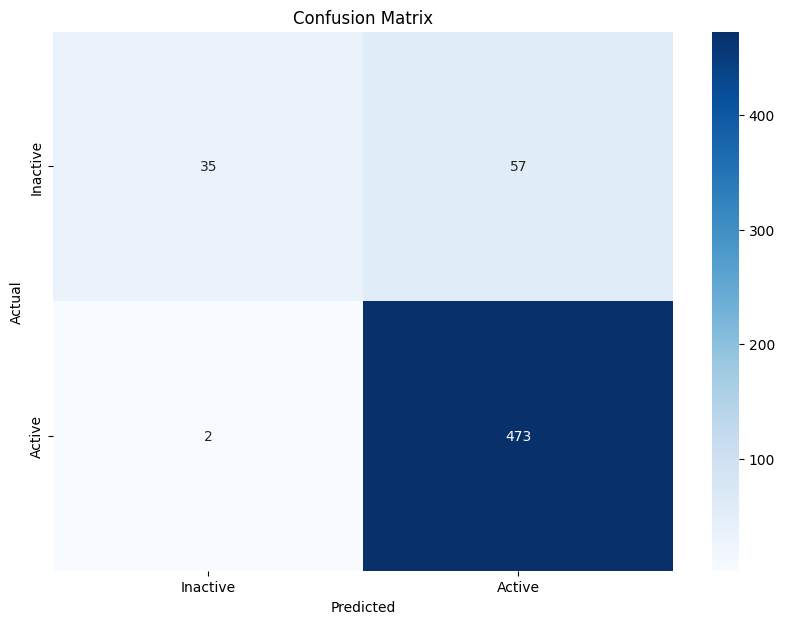

In [41]:
conf_matrix = confusion_matrix(y_test, y_pred)

import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [42]:
calc_metrics(final_model_rf)

Accuracy: 0.8959
Balanced Acc.: 0.6881
Precision: 0.8925
Recall: 0.9958
F1 Score: 0.9413
ROC-AUC: 0.9321
MCC: 0.5616
Specificity: 0.3804
Sensitivity: 0.9958
AUPRC: 0.9834


In [43]:
calc_loss(final_model_rf)

Log Loss(Test): 0.27129949666371145
Log Loss(Train): 0.1107684269429949
Focal Loss (Test Set): 0.0202


In [44]:
save_model(final_model_rf, best_params, "random_forest_bioactivity_model")

Model and metadata saved to saved_model/ml_models/ChemBERTa-zinc-base-v1/


In [46]:
# shap_plot(final_model_rf)

In [48]:
# lime_plot(final_model_rf)

##### LightGBM

In [50]:
import optuna
import lightgbm as lgbm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def objective(trial):
    param = {
        "objective": "binary",
        "metric": "auc",
        "verbosity": -1,
        "boosting_type": trial.suggest_categorical("boosting_type", ["gbdt", "goss", "rf"]),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 7, 128),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-2, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 10.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100, step=10),
    }
    if param["boosting_type"] == "goss":
        param["top_rate"] = trial.suggest_float("top_rate", 0.1, 0.4)
        param["other_rate"] = trial.suggest_float("other_rate", 0.05, 0.3)
    elif param["boosting_type"] == "rf":
        param["bagging_freq"] = trial.suggest_int("bagging_freq", 1, 10)
        param["bagging_fraction"] = trial.suggest_float("bagging_fraction", 0.5, 1.0)
    
    # Convert to Dataset for LightGBM
    train_data = lgbm.Dataset(X_train, label=y_train)
    val_data = lgbm.Dataset(X_val, label=y_val)
    
    # Train model with early stopping
    model = lgbm.train(
        param,
        train_data,
        valid_sets=[val_data],
        num_boost_round=param["n_estimators"]
    )
    
    # Predict probabilities for AUC
    preds_proba = model.predict(X_val)
    auc = roc_auc_score(y_val, preds_proba)

    return 1.0-auc

study = optuna.create_study()
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)

# Train final model with best params
best_params = study.best_params
best_params.update({"objective": "binary", "metric": "auc", "verbosity": -1})
final_model_lgbm = lgbm.LGBMClassifier(**best_params)
final_model_lgbm.fit(X_train, y_train)
y_pred = final_model_lgbm.predict(X_test)
print("Final AUC:", roc_auc_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

[I 2025-10-26 22:05:35,258] A new study created in memory with name: no-name-19c58f5f-6909-488a-a25f-ac565e5bffc1


[I 2025-10-26 22:05:35,829] Trial 0 finished with value: 0.1442243967096798 and parameters: {'boosting_type': 'gbdt', 'max_depth': 4, 'num_leaves': 104, 'learning_rate': 0.0171254766456112, 'n_estimators': 200, 'subsample': 0.7427417374136321, 'colsample_bytree': 0.7441906157974256, 'reg_lambda': 2.738760836891363, 'reg_alpha': 1.037086363003299, 'min_child_samples': 18, 'scale_pos_weight': 3.2035219735551137, 'min_data_in_leaf': 80}. Best is trial 0 with value: 0.1442243967096798.
[I 2025-10-26 22:05:36,515] Trial 1 finished with value: 0.18346263303574895 and parameters: {'boosting_type': 'rf', 'max_depth': 8, 'num_leaves': 89, 'learning_rate': 0.16591122862337396, 'n_estimators': 250, 'subsample': 0.9887968786693696, 'colsample_bytree': 0.8376127999050292, 'reg_lambda': 0.7159880024170725, 'reg_alpha': 0.016261942949994914, 'min_child_samples': 10, 'scale_pos_weight': 5.98133072172808, 'min_data_in_leaf': 100, 'bagging_freq': 1, 'bagging_fraction': 0.7083802415981801}. Best is trial

Best trial:
FrozenTrial(number=21, state=1, values=[0.055865268410588365], datetime_start=datetime.datetime(2025, 10, 26, 22, 5, 58, 198712), datetime_complete=datetime.datetime(2025, 10, 26, 22, 5, 59, 615202), params={'boosting_type': 'goss', 'max_depth': 7, 'num_leaves': 31, 'learning_rate': 0.11497459396287503, 'n_estimators': 400, 'subsample': 0.8000171660619548, 'colsample_bytree': 0.5690492420363171, 'reg_lambda': 1.4020970966337238, 'reg_alpha': 0.4434550662940739, 'min_child_samples': 39, 'scale_pos_weight': 5.348624049061128, 'min_data_in_leaf': 30, 'top_rate': 0.16105523901643826, 'other_rate': 0.24365802014620436}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'boosting_type': CategoricalDistribution(choices=('gbdt', 'goss', 'rf')), 'max_depth': IntDistribution(high=12, log=False, low=3, step=1), 'num_leaves': IntDistribution(high=128, log=False, low=7, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.001, step=None), 'n_estimat

In [51]:
calc_metrics(final_model_lgbm)

Accuracy: 0.9101
Balanced Acc.: 0.7579
Precision: 0.9157
Recall: 0.9832
F1 Score: 0.9482
ROC-AUC: 0.9572
MCC: 0.6324
Specificity: 0.5326
Sensitivity: 0.9832
AUPRC: 0.9910


In [52]:
calc_loss(final_model_lgbm)

Log Loss(Test): 0.2957433684179378
Log Loss(Train): 0.0045911877069715395
Focal Loss (Test Set): 0.0631


In [53]:
save_model(final_model_lgbm, best_params, "lightgbm_bioactivity_model")

Model and metadata saved to saved_model/ml_models/ChemBERTa-zinc-base-v1/


In [54]:
# shap_plot(final_model_lgbm)

In [55]:
# lime_plot(final_model_lgbm)

##### CatBoost

In [56]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def objective(trial):
    param = {
        "objective": "Logloss",
        "eval_metric": "AUC",
        "verbose": False,
        "boosting_type": "Plain",  # or "Ordered" for better quality but slower
        "depth": trial.suggest_int("depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "iterations": trial.suggest_int("iterations", 10, 500),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "random_strength": trial.suggest_float("random_strength", 0, 2),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 5.0),
        "thread_count": -1
    }
    model = CatBoostClassifier(**param)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    preds = model.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, preds)

    return 1.0 - auc  # Optuna minimizes, so invert AUC

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)

# Train final model with best params
best_params = study.best_params
best_params.update({
    "objective": "Logloss",
    "eval_metric": "AUC",
    "verbose": False,
    "boosting_type": "Plain"
})
final_model_cat = CatBoostClassifier(**best_params)
final_model_cat.fit(X_train, y_train)
y_pred = final_model_cat.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

[I 2025-10-26 22:06:38,434] A new study created in memory with name: no-name-cdd66f34-4eac-4fca-a648-62395c96a000
[I 2025-10-26 22:06:41,516] Trial 0 finished with value: 0.0912245136641846 and parameters: {'depth': 3, 'learning_rate': 0.23789873116376709, 'iterations': 427, 'l2_leaf_reg': 2.0924842106994928, 'bagging_temperature': 0.752397403580466, 'random_strength': 1.2321684422799903, 'border_count': 157, 'scale_pos_weight': 2.7336781993426245}. Best is trial 0 with value: 0.0912245136641846.
[I 2025-10-26 22:06:42,852] Trial 1 finished with value: 0.13309422634595147 and parameters: {'depth': 6, 'learning_rate': 0.1906500124242922, 'iterations': 71, 'l2_leaf_reg': 8.87797082722186, 'bagging_temperature': 0.368385936947241, 'random_strength': 0.5886058529957892, 'border_count': 121, 'scale_pos_weight': 3.767494543694511}. Best is trial 0 with value: 0.0912245136641846.
[I 2025-10-26 22:09:45,076] Trial 2 finished with value: 0.07372032279443286 and parameters: {'depth': 11, 'learni

Best trial:
FrozenTrial(number=26, state=1, values=[0.06186893298506879], datetime_start=datetime.datetime(2025, 10, 26, 22, 31, 42, 774454), datetime_complete=datetime.datetime(2025, 10, 26, 22, 32, 10, 179090), params={'depth': 8, 'learning_rate': 0.1630594620204531, 'iterations': 349, 'l2_leaf_reg': 1.403627951472572, 'bagging_temperature': 0.43636991616823895, 'random_strength': 0.3998255781713677, 'border_count': 216, 'scale_pos_weight': 1.0815483398278478}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'depth': IntDistribution(high=12, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.001, step=None), 'iterations': IntDistribution(high=500, log=False, low=10, step=1), 'l2_leaf_reg': FloatDistribution(high=10.0, log=False, low=1.0, step=None), 'bagging_temperature': FloatDistribution(high=1.0, log=False, low=0.0, step=None), 'random_strength': FloatDistribution(high=2.0, log=False, low=0.0, step=None), 'border_count': 

In [57]:
calc_metrics(final_model_cat)

Accuracy: 0.9118
Balanced Acc.: 0.7546
Precision: 0.9142
Recall: 0.9874
F1 Score: 0.9494
ROC-AUC: 0.9367
MCC: 0.6394
Specificity: 0.5217
Sensitivity: 0.9874
AUPRC: 0.9840


In [58]:
calc_loss(final_model_cat)

Log Loss(Test): 0.2662826100584912
Log Loss(Train): 0.005918250415755267
Focal Loss (Test Set): 0.0525


In [59]:
save_model(final_model_cat, best_params, "catboost_bioactivity_model")

Model and metadata saved to saved_model/ml_models/ChemBERTa-zinc-base-v1/


In [60]:
# shap_plot(final_model_cat) 

In [61]:
# lime_plot(final_model_cat)

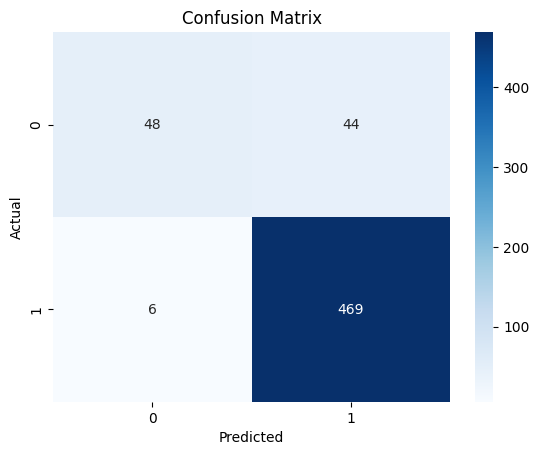

In [62]:
plot_confusion_matrix(final_model_cat)

##### ExtraTree Classifier

In [63]:
import optuna
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Calculate class imbalance (if needed)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1")

def objective(trial):
    """
    Objective function for Optuna to optimize ExtraTreesClassifier
    """
    
    param = {
        # Number of trees in the forest
        "n_estimators": trial.suggest_int("n_estimators", 10, 500),
        
        # Maximum depth of the tree
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        
        # Minimum samples required to split an internal node
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        
        # Minimum samples required at a leaf node
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        
        # Number of features to consider when looking for the best split
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None, 0.3, 0.5, 0.7, 1.0]),
        
        # Whether to use bootstrap samples
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        
        # --- CLASS IMBALANCE HANDLING ---
        # Option 1: Use automatic balancing
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample", None]),
        
        # Option 2: Use fixed calculated weight (uncomment and comment out Option 1)
        # "class_weight": {0: 1.0, 1: scale_pos_weight},
        
        # Option 3: Tune the minority class weight (uncomment and comment out Option 1)
        # "class_weight": {0: 1.0, 1: trial.suggest_float("minority_weight", 1.0, 10.0)},
        
        # --- ADDITIONAL PARAMETERS ---
        # Minimum weighted fraction of samples required at leaf
        "min_weight_fraction_leaf": trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.1),
        
        # Maximum number of leaf nodes
        "max_leaf_nodes": trial.suggest_categorical("max_leaf_nodes", [None, 10, 20, 50, 100]),
        
        # Minimum impurity decrease for split
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 0.0, 0.2),
        
        # Complexity parameter for pruning
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.1),
        
        # Maximum number of samples when bootstrap is True
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0) if trial.params.get("bootstrap", True) else None,
        
        # Quality of split criterion
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        
        # Other settings
        "random_state": 42,
        "n_jobs": -1,  # Use all CPU cores
        "warm_start": False,
        "oob_score": False  # Out-of-bag score (only if bootstrap=True)
    }
    
    # Remove max_samples if bootstrap is False
    if not param["bootstrap"]:
        param.pop("max_samples", None)
    
    # Build and train model
    model = ExtraTreesClassifier(**param)
    model.fit(X_train, y_train)
    
    # Predict probabilities for AUC calculation
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)

    # Alternative: Use accuracy
    # preds = model.predict(X_test)
    # accuracy = accuracy_score(y_test, preds)
    # return 1.0 - accuracy
    
    # Alternative: Use F1 score
    # preds = model.predict(X_test)
    # f1 = f1_score(y_test, preds)
    # return 1.0 - f1
    
    return 1.0 - auc  # Optuna minimizes


def objective_with_cv(trial):
    """
    Objective function with cross-validation for more robust evaluation
    """
    
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample", None]),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "random_state": 42,
        "n_jobs": -1
    }
    
    model = ExtraTreesClassifier(**param)
    
    # 5-fold cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    
    return 1.0 - scores.mean()


# Create study and optimize
print("Starting hyperparameter optimization...")
study = optuna.create_study(
    direction="minimize",
    study_name="extratrees_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run optimization
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Print results
print("\n" + "="*50)
print("OPTIMIZATION RESULTS")
print("="*50)
print(f"Best trial: {study.best_trial.number}")
print(f"Best AUC: {1 - study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
print("\n" + "="*50)
print("TRAINING FINAL MODEL")
print("="*50)

best_params = study.best_params.copy()
best_params.update({
    "random_state": 42,
    "n_jobs": -1
})

final_model_et = ExtraTreesClassifier(**best_params)
final_model_et.fit(X_train, y_train)

# Evaluate final model
y_pred = final_model_et.predict(X_test)
y_pred_proba = final_model_et.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(f"\nFinal Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred):.4f}")


print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
print(f"\nTop 10 Most Important Features:")
feature_importance = final_model_et.feature_importances_
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"Feature_{i}" for i in range(X_train.shape[1])]
importance_df = sorted(zip(feature_names, feature_importance), key=lambda x: x[1], reverse=True)
for name, importance in importance_df[:10]:
    print(f"  {name}: {importance:.4f}")

# Optuna visualization (optional)
try:
    import plotly
    
    # Plot optimization history
    fig1 = optuna.visualization.plot_optimization_history(study)
    fig1.write_html("optuna_history.html")
    
    # Plot parameter importances
    fig2 = optuna.visualization.plot_param_importances(study)
    fig2.write_html("optuna_param_importances.html")
    
    # Plot parallel coordinate
    fig3 = optuna.visualization.plot_parallel_coordinate(study)
    fig3.write_html("optuna_parallel_coordinate.html")
    
    print("\nOptuna visualizations saved as HTML files!")
except ImportError:
    print("\nInstall plotly for visualizations: pip install plotly")

[I 2025-10-26 23:11:07,492] A new study created in memory with name: extratrees_optimization


Class imbalance ratio: 0.22:1
Starting hyperparameter optimization...


Best trial: 0. Best value: 0.344753:   2%|▏         | 1/50 [00:00<00:22,  2.15it/s]

[I 2025-10-26 23:11:07,956] Trial 0 finished with value: 0.3447526412225643 and parameters: {'n_estimators': 193, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 0.3, 'bootstrap': True, 'class_weight': 'balanced', 'min_weight_fraction_leaf': 0.030424224295953775, 'max_leaf_nodes': 50, 'min_impurity_decrease': 0.058428929707043636, 'ccp_alpha': 0.03663618432936917, 'max_samples': 0.728034992108518, 'criterion': 'gini'}. Best is trial 0 with value: 0.3447526412225643.


Best trial: 0. Best value: 0.344753:   4%|▍         | 2/50 [00:01<00:33,  1.43it/s]

...

[I 2025-10-26 23:11:53,978] Trial 47 finished with value: 0.5 and parameters: {'n_estimators': 357, 'max_depth': 7, 'min_samples_split': 19, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': 'balanced_subsample', 'min_weight_fraction_leaf': 0.008505866706839761, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.19930688138536212, 'ccp_alpha': 0.01459916718817732, 'max_samples': 0.9691833711775796, 'criterion': 'entropy'}. Best is trial 22 with value: 0.14219718529492031.


Best trial: 22. Best value: 0.142197:  98%|█████████▊| 49/50 [00:47<00:00,  1.20it/s]

[I 2025-10-26 23:11:54,649] Trial 48 finished with value: 0.24857705352617832 and parameters: {'n_estimators': 324, 'max_depth': 4, 'min_samples_split': 14, 'min_samples_leaf': 10, 'max_features': 1.0, 'bootstrap': False, 'class_weight': 'balanced_subsample', 'min_weight_fraction_leaf': 0.017763508074572467, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.032409840366547815, 'ccp_alpha': 0.008928033534318685, 'criterion': 'gini'}. Best is trial 22 with value: 0.14219718529492031.


Best trial: 22. Best value: 0.142197: 100%|██████████| 50/50 [00:48<00:00,  1.04it/s]


[I 2025-10-26 23:11:55,762] Trial 49 finished with value: 0.18114303535924536 and parameters: {'n_estimators': 283, 'max_depth': 30, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': None, 'bootstrap': True, 'class_weight': 'balanced_subsample', 'min_weight_fraction_leaf': 0.0034866261202964816, 'max_leaf_nodes': 100, 'min_impurity_decrease': 0.007457831195877087, 'ccp_alpha': 0.0011588217531043029, 'max_samples': 0.9283489764318196, 'criterion': 'gini'}. Best is trial 22 with value: 0.14219718529492031.

OPTIMIZATION RESULTS
Best trial: 22
Best AUC: 0.8578

Best hyperparameters:
  n_estimators: 434
  max_depth: 5
  min_samples_split: 18
  min_samples_leaf: 10
  max_features: None
  bootstrap: True
  class_weight: balanced_subsample
  min_weight_fraction_leaf: 0.011210108744296149
  max_leaf_nodes: None
  min_impurity_decrease: 0.0001236837284415821
  ccp_alpha: 0.0008376664592552275
  max_samples: 0.9558991976398594
  criterion: gini

TRAINING FINAL MODEL

Final Model Pe

In [64]:
calc_metrics(final_model_et)

Accuracy: 0.8642
Balanced Acc.: 0.7919
Precision: 0.9364
Recall: 0.8989
F1 Score: 0.9173
ROC-AUC: 0.8848
MCC: 0.5424
Specificity: 0.6848
Sensitivity: 0.8989
AUPRC: 0.9717


In [65]:
calc_loss(final_model_et)

Log Loss(Test): 0.4527248027042051
Log Loss(Train): 0.4292618095722987
Focal Loss (Test Set): 0.0222


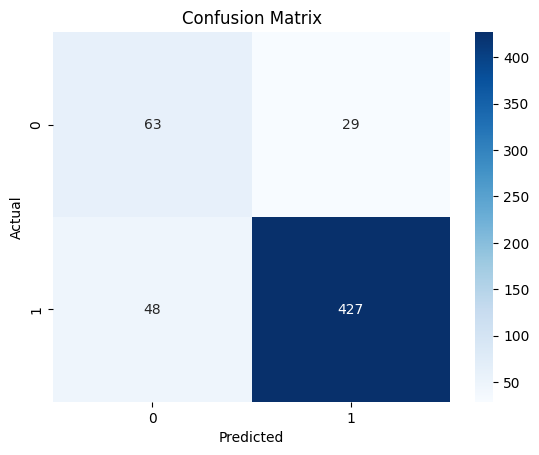

In [66]:
plot_confusion_matrix(final_model_et)

In [67]:
save_model(final_model_et, best_params, "extratree_bioactivity_model")

Model and metadata saved to saved_model/ml_models/ChemBERTa-zinc-base-v1/


In [68]:
# shap_plot(final_model_et)

In [69]:
# lime_plot(final_model_et)

#### CNN

In [70]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [71]:
# Calculate class weights for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
class_weights = torch.tensor([1.0, neg_count / pos_count], dtype=torch.float32).to(device)
print(f"Class imbalance ratio: {neg_count / pos_count:.2f}:1")

Class imbalance ratio: 0.22:1


In [72]:
class CNN1D(nn.Module):
    """
    1D CNN for tabular data classification
    """
    def __init__(self, input_size, trial):
        super(CNN1D, self).__init__()
        
        # Hyperparameters from Optuna
        n_conv_layers = trial.suggest_int("n_conv_layers", 1, 4)
        n_fc_layers = trial.suggest_int("n_fc_layers", 1, 3)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
        
        # Build convolutional layers
        conv_layers = []
        in_channels = 1
        current_size = input_size
        
        for i in range(n_conv_layers):
            out_channels = trial.suggest_int(f"conv_{i}_out_channels", 16, 128, step=16)
            kernel_size = trial.suggest_int(f"conv_{i}_kernel_size", 3, 7, step=2)
            
            conv_layers.append(nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size//2))
            conv_layers.append(nn.BatchNorm1d(out_channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.Dropout(dropout_rate))
            
            # Optional pooling
            if trial.suggest_categorical(f"conv_{i}_pooling", [True, False]):
                pool_size = trial.suggest_int(f"conv_{i}_pool_size", 2, 3)
                conv_layers.append(nn.MaxPool1d(pool_size))
                current_size = current_size // pool_size
            
            in_channels = out_channels
        
        self.conv_block = nn.Sequential(*conv_layers)
        
        # Calculate flattened size
        flattened_size = out_channels * current_size
        
        # Build fully connected layers
        fc_layers = []
        prev_size = flattened_size
        
        for i in range(n_fc_layers):
            fc_size = trial.suggest_int(f"fc_{i}_size", 32, 512, step=32)
            fc_layers.append(nn.Linear(prev_size, fc_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(dropout_rate))
            prev_size = fc_size
        
        # Output layer
        fc_layers.append(nn.Linear(prev_size, 2))
        
        self.fc_block = nn.Sequential(*fc_layers)
    
    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension: (batch, features) -> (batch, 1, features)
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_block(x)
        return x

In [73]:
class CNN2D(nn.Module):
    """
    2D CNN for image-like data classification
    Assumes input is reshaped to (batch, channels, height, width)
    """
    def __init__(self, input_channels, input_height, input_width, trial):
        super(CNN2D, self).__init__()
        
        # Hyperparameters from Optuna
        n_conv_layers = trial.suggest_int("n_conv_layers", 2, 5)
        n_fc_layers = trial.suggest_int("n_fc_layers", 1, 3)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
        
        # Build convolutional layers
        conv_layers = []
        in_channels = input_channels
        current_h, current_w = input_height, input_width
        
        for i in range(n_conv_layers):
            out_channels = trial.suggest_int(f"conv_{i}_out_channels", 16, 128, step=16)
            kernel_size = trial.suggest_int(f"conv_{i}_kernel_size", 3, 7, step=2)
            
            conv_layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=kernel_size//2))
            conv_layers.append(nn.BatchNorm2d(out_channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.Dropout2d(dropout_rate))
            
            # Pooling
            if trial.suggest_categorical(f"conv_{i}_pooling", [True, False]):
                pool_size = trial.suggest_int(f"conv_{i}_pool_size", 2, 3)
                conv_layers.append(nn.MaxPool2d(pool_size))
                current_h = current_h // pool_size
                current_w = current_w // pool_size
            
            in_channels = out_channels
        
        self.conv_block = nn.Sequential(*conv_layers)
        
        # Calculate flattened size
        flattened_size = out_channels * current_h * current_w
        
        # Build fully connected layers
        fc_layers = []
        prev_size = flattened_size
        
        for i in range(n_fc_layers):
            fc_size = trial.suggest_int(f"fc_{i}_size", 64, 512, step=64)
            fc_layers.append(nn.Linear(prev_size, fc_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(dropout_rate))
            prev_size = fc_size
        
        # Output layer
        fc_layers.append(nn.Linear(prev_size, 2))
        
        self.fc_block = nn.Sequential(*fc_layers)
    
    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_block(x)
        return x

In [74]:

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in dataloader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    
    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    """Evaluate model"""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.numpy())
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


In [75]:
def objective_1d(trial):
    """
    Objective function for 1D CNN (for tabular data)
    """
    
    # Prepare data
    X_train_tensor = torch.FloatTensor(X_train.values if hasattr(X_train, 'values') else X_train)
    y_train_tensor = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train)
    X_val_tensor = torch.FloatTensor(X_val.values if hasattr(X_val, 'values') else X_val)
    y_val_tensor = torch.LongTensor(y_val.values if hasattr(y_val, 'values') else y_val)
    X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
    y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)
    
    # Hyperparameters
    batch_size = trial.suggest_int("batch_size", 16, 128, step=16)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    n_epochs = trial.suggest_int("n_epochs", 10, 100)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "SGD", "RMSprop"])
    
    # Create dataloaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Create model
    input_size = X_train_tensor.shape[1]
    model = CNN1D(input_size, trial).to(device)
    
    # Loss function with class weights
    use_class_weights = trial.suggest_categorical("use_class_weights", [True, False])
    if use_class_weights:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()
    
    # Optimizer
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        momentum = trial.suggest_float("momentum", 0.8, 0.99)
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
    else:  # RMSprop
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    # Learning rate scheduler
    use_scheduler = trial.suggest_categorical("use_scheduler", [True, False])
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    
    # Training loop
    best_auc = 0
    patience_counter = 0
    early_stopping_patience = 10
    
    for epoch in range(n_epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Evaluate
        y_true, y_pred, y_prob = evaluate(model, val_loader, device)
        auc = roc_auc_score(y_true, y_prob)
        
        # Learning rate scheduling
        if use_scheduler:
            scheduler.step(train_loss)
        
        # Early stopping
        if auc > best_auc:
            best_auc = auc
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= early_stopping_patience:
            break
        
        # Report to Optuna for pruning
        trial.report(1.0 - auc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return 1.0 - best_auc

In [76]:

def objective_2d(trial):
    """
    Objective function for 2D CNN (for image data)
    Assumes X_train/X_test are already in shape (N, C, H, W) or will be reshaped
    """
    
    # Reshape data if needed (example: reshape to 28x28 images)
    # Adjust these dimensions based on your data
    n_samples = X_train.shape[0]
    input_channels = 1
    input_height = 28
    input_width = 28
    
    # Reshape to (N, C, H, W)
    X_train_reshaped = X_train.values.reshape(n_samples, input_channels, input_height, input_width)
    X_test_reshaped = X_test.values.reshape(X_test.shape[0], input_channels, input_height, input_width)
    
    X_train_tensor = torch.FloatTensor(X_train_reshaped)
    y_train_tensor = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train)
    X_test_tensor = torch.FloatTensor(X_test_reshaped)
    y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)
    
    # Hyperparameters
    batch_size = trial.suggest_int("batch_size", 16, 128, step=16)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    n_epochs = trial.suggest_int("n_epochs", 10, 100)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "SGD"])
    
    # Create dataloaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Create model
    model = CNN2D(input_channels, input_height, input_width, trial).to(device)
    
    # Loss and optimizer (similar to 1D version)
    use_class_weights = trial.suggest_categorical("use_class_weights", [True, False])
    criterion = nn.CrossEntropyLoss(weight=class_weights if use_class_weights else None)
    
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else:  # SGD
        momentum = trial.suggest_float("momentum", 0.8, 0.99)
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
    
    # Training loop (same as 1D)
    best_auc = 0
    for epoch in range(n_epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        y_true, y_pred, y_prob = evaluate(model, test_loader, device)
        auc = roc_auc_score(y_true, y_prob)
        
        if auc > best_auc:
            best_auc = auc
        
        trial.report(1.0 - auc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return 1.0 - best_auc


##### 1d cnn

In [77]:
# Run optimization
print("Starting CNN hyperparameter optimization...")
print("="*60)

# Choose which objective to use
study = optuna.create_study(
    direction="minimize",
    study_name="cnn_optimization",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)

# Optimize (use objective_1d for tabular data, objective_2d for images)
study.optimize(objective_1d, n_trials=30, show_progress_bar=True)

# Print results
print("\n" + "="*60)
print("OPTIMIZATION RESULTS")
print("="*60)
print(f"Best trial: {study.best_trial.number}")
print(f"Best AUC: {1 - study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
print("\n" + "="*60)
print("TRAINING FINAL MODEL")
print("="*60)

best_params = study.best_params

# Recreate best trial for model architecture
best_trial = study.best_trial

# Prepare data
X_train_tensor = torch.FloatTensor(X_train.values if hasattr(X_train, 'values') else X_train)
y_train_tensor = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train)
X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = best_params['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Create final model
input_size = X_train_tensor.shape[1]
final_model = CNN1D(input_size, best_trial).to(device)

# Train final model
criterion = nn.CrossEntropyLoss(weight=class_weights if best_params['use_class_weights'] else None)

if best_params['optimizer'] == "Adam":
    optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'], 
                          weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == "AdamW":
    optimizer = optim.AdamW(final_model.parameters(), lr=best_params['learning_rate'], 
                           weight_decay=best_params['weight_decay'])
else:
    optimizer = optim.SGD(final_model.parameters(), lr=best_params['learning_rate'], 
                         momentum=best_params.get('momentum', 0.9), 
                         weight_decay=best_params['weight_decay'])

for epoch in range(best_params['n_epochs']):
    train_loss = train_epoch(final_model, train_loader, criterion, optimizer, device)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{best_params['n_epochs']}, Loss: {train_loss:.4f}")

# Final evaluation
y_true, y_pred, y_prob = evaluate(final_model, test_loader, device)

print(f"\nFinal Model Performance:")
print(f"  Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
print(f"  F1 Score: {f1_score(y_true, y_pred):.4f}")

from sklearn.metrics import classification_report, confusion_matrix
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred))

# Save model
torch.save(final_model.state_dict(), 'best_cnn_model.pth')
print("\nModel saved as 'best_cnn_model.pth'")

[I 2025-10-26 23:12:00,172] A new study created in memory with name: cnn_optimization


Starting CNN hyperparameter optimization...


Best trial: 0. Best value: 0.111107:   3%|▎         | 1/30 [00:29<14:22, 29.74s/it]

[I 2025-10-26 23:12:29,906] Trial 0 finished with value: 0.11110677946278902 and parameters: {'batch_size': 48, 'learning_rate': 0.0071144760093434225, 'weight_decay': 0.000157029708840554, 'n_epochs': 64, 'optimizer': 'RMSprop', 'n_conv_layers': 3, 'n_fc_layers': 3, 'dropout_rate': 0.10823379771832098, 'conv_0_out_channels': 128, 'conv_0_kernel_size': 7, 'conv_0_pooling': True, 'conv_0_pool_size': 2, 'conv_1_out_channels': 48, 'conv_1_kernel_size': 5, 'conv_1_pooling': True, 'conv_1_pool_size': 3, 'conv_2_out_channels': 32, 'conv_2_kernel_size': 3, 'conv_2_pooling': False, 'fc_0_size': 416, 'fc_1_size': 128, 'fc_2_size': 288, 'use_class_weights': True, 'use_scheduler': True}. Best is trial 0 with value: 0.11110677946278902.


Best trial: 0. Best value: 0.111107:   7%|▋         | 2/30 [00:38<08:08, 17.44s/it]

...

[I 2025-10-26 23:16:47,544] Trial 27 finished with value: 0.1344392031499747 and parameters: {'batch_size': 16, 'learning_rate': 0.0021884592640063244, 'weight_decay': 6.688166002699435e-05, 'n_epochs': 11, 'optimizer': 'AdamW', 'n_conv_layers': 1, 'n_fc_layers': 3, 'dropout_rate': 0.26590981626179533, 'conv_0_out_channels': 64, 'conv_0_kernel_size': 7, 'conv_0_pooling': False, 'fc_0_size': 480, 'fc_1_size': 320, 'fc_2_size': 128, 'use_class_weights': False, 'use_scheduler': False}. Best is trial 26 with value: 0.08635140930178165.


Best trial: 26. Best value: 0.0863514:  97%|█████████▋| 29/30 [04:59<00:14, 14.82s/it]

[I 2025-10-26 23:16:59,419] Trial 28 pruned. 


Best trial: 26. Best value: 0.0863514: 100%|██████████| 30/30 [05:14<00:00, 10.47s/it]


[I 2025-10-26 23:17:14,204] Trial 29 pruned. 

OPTIMIZATION RESULTS
Best trial: 26
Best AUC: 0.9136

Best hyperparameters:
  batch_size: 16
  learning_rate: 0.00025208832642424324
  weight_decay: 2.047730205435353e-05
  n_epochs: 30
  optimizer: AdamW
  n_conv_layers: 1
  n_fc_layers: 3
  dropout_rate: 0.19937383033805053
  conv_0_out_channels: 64
  conv_0_kernel_size: 7
  conv_0_pooling: False
  fc_0_size: 448
  fc_1_size: 320
  fc_2_size: 96
  use_class_weights: False
  use_scheduler: False

TRAINING FINAL MODEL
Epoch 10/30, Loss: 0.2819
Epoch 20/30, Loss: 0.2216
Epoch 30/30, Loss: 0.1804

Final Model Performance:
  Accuracy: 0.9295
  ROC-AUC: 0.9424
  F1 Score: 0.9586

Confusion Matrix:
[[ 64  28]
 [ 12 463]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.70      0.76        92
           1       0.94      0.97      0.96       475

    accuracy                           0.93       567
   macro avg       0.89      0.84   

Accuracy: 0.9295
Balanced Acc.: 0.8352
Precision: 0.9430
Recall: 0.9747
F1 Score: 0.9586
ROC-AUC: 0.9424
MCC: 0.7255
Specificity: 0.6957
Sensitivity: 0.9747
AUPRC: 0.9860


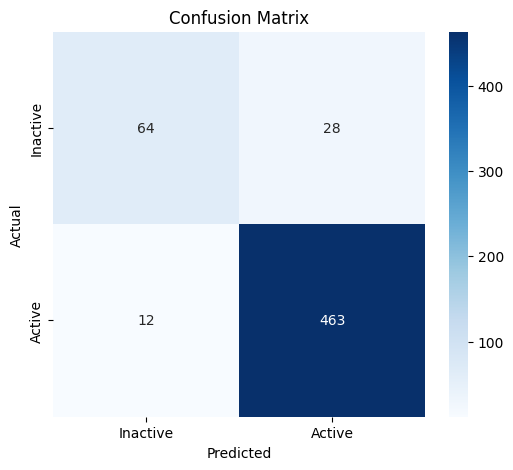

              precision    recall  f1-score   support

           0       0.84      0.70      0.76        92
           1       0.94      0.97      0.96       475

    accuracy                           0.93       567
   macro avg       0.89      0.84      0.86       567
weighted avg       0.93      0.93      0.93       567



In [78]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Robust confusion matrix plot that works for sklearn-like models or the trained PyTorch CNN
import matplotlib.pyplot as plt

# Get predictions and true labels
if hasattr(final_model, "predict") and 'X_test' in globals():
    y_pred_local = final_model.predict(X_test)
    y_true_local = y_test.values if hasattr(y_test, "values") else y_test
elif 'y_pred' in globals() and 'y_true' in globals() and 'y_pred' in globals():
    y_pred_local = y_pred
    y_true_local = y_true
    y_prob_local = y_prob
else:
    # Fall back to using the PyTorch model and test_loader
    final_model.eval()
    preds, trues, probs = [], [], []
    with torch.no_grad():
        for bx, by in test_loader:
            bx = bx.to(device)
            out = final_model(bx)
            pred = torch.argmax(out, dim=1).cpu().numpy()
            prob = torch.softmax(out, dim=1)[:, 1]
            preds.append(pred)
            trues.append(by.numpy())
            probs.append(prob)
    y_pred_local = np.concatenate(preds)
    y_true_local = np.concatenate(trues)
    y_prob_local = np.concatenate(probs)
# Plot
accuracy = accuracy_score(y_true_local, y_pred_local)
balanced_acc = balanced_accuracy_score(y_true_local, y_pred_local)
precision = precision_score(y_true_local, y_pred_local)
recall = recall_score(y_true_local, y_pred_local)  # This is also Sensitivity
f1 = f1_score(y_true_local, y_pred_local)
roc_auc = roc_auc_score(y_true_local, y_prob_local)
mcc = matthews_corrcoef(y_true_local, y_pred_local)
auprc = average_precision_score(y_true_local, y_prob_local)  # Area Under Precision-Recall Curve

# For Specificity: Derive from confusion matrix
cm = confusion_matrix(y_true_local, y_pred_local)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = recall  # Same as recall

# Step 3: Print or store results (e.g., to fill your table)
print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Acc.: {balanced_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"AUPRC: {auprc:.4f}")
cm = confusion_matrix(y_true_local, y_pred_local)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print(classification_report(y_true_local, y_pred_local))

##### 2d

In [79]:
# # Run optimization
# print("Starting CNN hyperparameter optimization...")
# print("="*60)

# # Choose which objective to use
# study = optuna.create_study(
#     direction="minimize",
#     study_name="cnn_optimization",
#     sampler=optuna.samplers.TPESampler(seed=42),
#     pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
# )

# # Optimize (use objective_1d for tabular data, objective_2d for images)
# study.optimize(objective_2d, n_trials=50, show_progress_bar=True)

# # Print results
# print("\n" + "="*60)
# print("OPTIMIZATION RESULTS")
# print("="*60)
# print(f"Best trial: {study.best_trial.number}")
# print(f"Best AUC: {1 - study.best_value:.4f}")
# print(f"\nBest hyperparameters:")
# for key, value in study.best_params.items():
#     print(f"  {key}: {value}")

# # Train final model with best parameters
# print("\n" + "="*60)
# print("TRAINING FINAL MODEL")
# print("="*60)

# best_params = study.best_params

# # Recreate best trial for model architecture
# best_trial = study.best_trial

# # Prepare data
# X_train_tensor = torch.FloatTensor(X_train.values if hasattr(X_train, 'values') else X_train)
# y_train_tensor = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train)
# X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
# y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)

# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# batch_size = best_params['batch_size']
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# # Create final model
# input_size = X_train_tensor.shape[1]
# final_model = CNN1D(input_size, best_trial).to(device)

# # Train final model
# criterion = nn.CrossEntropyLoss(weight=class_weights if best_params['use_class_weights'] else None)

# if best_params['optimizer'] == "Adam":
#     optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'], 
#                           weight_decay=best_params['weight_decay'])
# elif best_params['optimizer'] == "AdamW":
#     optimizer = optim.AdamW(final_model.parameters(), lr=best_params['learning_rate'], 
#                            weight_decay=best_params['weight_decay'])
# else:
#     optimizer = optim.SGD(final_model.parameters(), lr=best_params['learning_rate'], 
#                          momentum=best_params.get('momentum', 0.9), 
#                          weight_decay=best_params['weight_decay'])

# for epoch in range(best_params['n_epochs']):
#     train_loss = train_epoch(final_model, train_loader, criterion, optimizer, device)
#     if (epoch + 1) % 10 == 0:
#         print(f"Epoch {epoch+1}/{best_params['n_epochs']}, Loss: {train_loss:.4f}")

# # Final evaluation
# y_true, y_pred, y_prob = evaluate(final_model, test_loader, device)

# print(f"\nFinal Model Performance:")
# print(f"  Accuracy: {accuracy_score(y_true, y_pred):.4f}")
# print(f"  ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
# print(f"  F1 Score: {f1_score(y_true, y_pred):.4f}")

# from sklearn.metrics import classification_report, confusion_matrix
# print(f"\nConfusion Matrix:")
# print(confusion_matrix(y_true, y_pred))
# print(f"\nClassification Report:")
# print(classification_report(y_true, y_pred))

# # Save model
# torch.save(final_model.state_dict(), 'best_cnn_model_2d.pth')
# print("\nModel saved as 'best_cnn_model_2d.pth'")

In [80]:
# from sklearn.metrics import confusion_matrix, classification_report
# import seaborn as sns

# # Robust confusion matrix plot that works for sklearn-like models or the trained PyTorch CNN
# import matplotlib.pyplot as plt

# # Get predictions and true labels
# if hasattr(final_model, "predict") and 'X_test' in globals():
#     y_pred_local = final_model.predict(X_test)
#     y_true_local = y_test.values if hasattr(y_test, "values") else y_test
# elif 'y_pred' in globals() and 'y_true' in globals() and 'y_pred' in globals():
#     y_pred_local = y_pred
#     y_true_local = y_true
#     y_prob_local = y_prob
# else:
#     # Fall back to using the PyTorch model and test_loader
#     final_model.eval()
#     preds, trues, probs = [], [], []
#     with torch.no_grad():
#         for bx, by in test_loader:
#             bx = bx.to(device)
#             out = final_model(bx)
#             pred = torch.argmax(out, dim=1).cpu().numpy()
#             prob = torch.softmax(out, dim=1)[:, 1]
#             preds.append(pred)
#             trues.append(by.numpy())
#             probs.append(prob)
#     y_pred_local = np.concatenate(preds)
#     y_true_local = np.concatenate(trues)
#     y_prob_local = np.concatenate(probs)
# # Plot
# accuracy = accuracy_score(y_true_local, y_pred_local)
# balanced_acc = balanced_accuracy_score(y_true_local, y_pred_local)
# precision = precision_score(y_true_local, y_pred_local)
# recall = recall_score(y_true_local, y_pred_local)  # This is also Sensitivity
# f1 = f1_score(y_true_local, y_pred_local)
# roc_auc = roc_auc_score(y_true_local, y_prob_local)
# mcc = matthews_corrcoef(y_true_local, y_pred_local)
# auprc = average_precision_score(y_true_local, y_prob_local)  # Area Under Precision-Recall Curve

# # For Specificity: Derive from confusion matrix
# cm = confusion_matrix(y_true_local, y_pred_local)
# tn, fp, fn, tp = cm.ravel()
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
# sensitivity = recall  # Same as recall

# # Step 3: Print or store results (e.g., to fill your table)
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Balanced Acc.: {balanced_acc:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1 Score: {f1:.4f}")
# print(f"ROC-AUC: {roc_auc:.4f}")
# print(f"MCC: {mcc:.4f}")
# print(f"Specificity: {specificity:.4f}")
# print(f"Sensitivity: {sensitivity:.4f}")
# print(f"AUPRC: {auprc:.4f}")
# cm = confusion_matrix(y_true_local, y_pred_local)
# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'])
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix')
# plt.show()

# # Print classification report
# print(classification_report(y_true_local, y_pred_local))

#### SVN

In [81]:
import optuna
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# ============================================================================
# SVM (Support Vector Machine) Optimization
# ============================================================================

print("="*70)
print("SVM HYPERPARAMETER OPTIMIZATION")
print("="*70)



# Calculate class weights for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1\n")

def objective_svm(trial):
    param = {
        # Kernel type
        "kernel": trial.suggest_categorical("kernel", ["linear", "rbf", "poly", "sigmoid"]),
        
        # Regularization parameter
        "C": trial.suggest_float("C", 1e-3, 100, log=True),
        
        # Kernel coefficient (for rbf, poly, sigmoid)
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
        
        # Degree for polynomial kernel
        "degree": trial.suggest_int("degree", 2, 5) if trial.params.get("kernel") == "poly" else 3,
        
        # Class weight for imbalance
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
        
        # Probability estimates (needed for ROC-AUC)
        "probability": True,
        
        # Tolerance for stopping criterion
        "tol": trial.suggest_float("tol", 1e-5, 1e-2, log=True),
        
        # Maximum iterations
        "max_iter": trial.suggest_int("max_iter", 100, 2000, step=100),
        
        # Shrinking heuristic
        "shrinking": trial.suggest_categorical("shrinking", [True, False])
    }
    
    # Remove degree if not polynomial kernel
    if param["kernel"] != "poly":
        param.pop("degree", None)
    
    model = SVC(**param)
    model.fit(X_train, y_train)
    
    # Predict probabilities for AUC
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)
    
    return 1.0 - auc  # Optuna minimizes, so invert AUC

# Create and run study
study_svm = optuna.create_study(
    direction="minimize",
    study_name="svm_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting SVM optimization...")
study_svm.optimize(objective_svm, n_trials=50, show_progress_bar=True)

print("\n" + "="*70)
print("SVM OPTIMIZATION RESULTS")
print("="*70)
print(f"Best trial: {study_svm.best_trial.number}")
print(f"Best AUC: {1 - study_svm.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_svm.best_params.items():
    print(f"  {key}: {value}")

# Train final SVM model with best params
print("\n" + "="*70)
print("TRAINING FINAL SVM MODEL")
print("="*70)

best_params_svm = study_svm.best_params.copy()
best_params_svm.update({
    "probability": True,
    "random_state": 42
})

final_model_svm = SVC(**best_params_svm)
final_model_svm.fit(X_train, y_train)

# Evaluate on test set
y_pred_svm = final_model_svm.predict(X_test)
y_pred_proba_svm = final_model_svm.predict_proba(X_test)[:, 1]

print(f"\nFinal SVM Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_proba_svm):.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

[I 2025-10-26 23:17:55,211] A new study created in memory with name: svm_optimization


SVM HYPERPARAMETER OPTIMIZATION
Class imbalance ratio: 0.22:1

Starting SVM optimization...


Best trial: 0. Best value: 0.540837:   2%|▏         | 1/50 [00:01<01:20,  1.64s/it]

[I 2025-10-26 23:17:56,850] Trial 0 finished with value: 0.5408366145569373 and parameters: {'kernel': 'rbf', 'C': 0.006026889128682512, 'gamma': 'scale', 'class_weight': 'balanced', 'tol': 0.001331121608073689, 'max_iter': 100, 'shrinking': True}. Best is trial 0 with value: 0.5408366145569373.


Best trial: 0. Best value: 0.540837:   4%|▍         | 2/50 [00:08<03:53,  4.87s/it]

...

[I 2025-10-26 23:27:04,462] Trial 47 finished with value: 0.1725078944290671 and parameters: {'kernel': 'rbf', 'C': 0.2932175191797779, 'gamma': 'auto', 'class_weight': None, 'tol': 0.0028275599154325283, 'max_iter': 1900, 'shrinking': False}. Best is trial 31 with value: 0.10432341819032409.


Best trial: 48. Best value: 0.103583:  98%|█████████▊| 49/50 [09:23<00:13, 13.83s/it]

[I 2025-10-26 23:27:18,782] Trial 48 finished with value: 0.10358270632723876 and parameters: {'kernel': 'rbf', 'C': 49.99755973501884, 'gamma': 'auto', 'class_weight': None, 'tol': 1.0189039058327592e-05, 'max_iter': 1700, 'shrinking': True}. Best is trial 48 with value: 0.10358270632723876.


Best trial: 48. Best value: 0.103583: 100%|██████████| 50/50 [09:35<00:00, 11.50s/it]


[I 2025-10-26 23:27:30,415] Trial 49 finished with value: 0.5 and parameters: {'kernel': 'sigmoid', 'C': 44.86544218826964, 'gamma': 'auto', 'class_weight': None, 'tol': 1.0352078944168953e-05, 'max_iter': 900, 'shrinking': True}. Best is trial 48 with value: 0.10358270632723876.

SVM OPTIMIZATION RESULTS
Best trial: 48
Best AUC: 0.8964

Best hyperparameters:
  kernel: rbf
  C: 49.99755973501884
  gamma: auto
  class_weight: None
  tol: 1.0189039058327592e-05
  max_iter: 1700
  shrinking: True

TRAINING FINAL SVM MODEL

Final SVM Model Performance:
  Accuracy: 0.9171
  ROC-AUC: 0.8951

Confusion Matrix:
[[ 61  31]
 [ 16 459]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.66      0.72        92
           1       0.94      0.97      0.95       475

    accuracy                           0.92       567
   macro avg       0.86      0.81      0.84       567
weighted avg       0.91      0.92      0.91       567



In [82]:
calc_metrics(final_model_svm)

Accuracy: 0.9171
Balanced Acc.: 0.8147
Precision: 0.9367
Recall: 0.9663
F1 Score: 0.9513
ROC-AUC: 0.8951
MCC: 0.6773
Specificity: 0.6630
Sensitivity: 0.9663
AUPRC: 0.9706


In [83]:


calc_loss(final_model_svm)

Log Loss(Test): 0.24752251013289478
Log Loss(Train): 0.07333820463396629
Focal Loss (Test Set): 0.0324


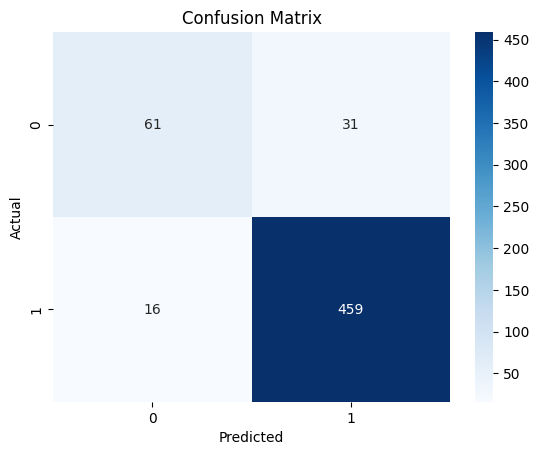

In [84]:

plot_confusion_matrix(final_model_svm)

In [85]:
save_model(final_model_svm, best_params_svm, "svm_bioactivity_model")

Model and metadata saved to saved_model/ml_models/ChemBERTa-zinc-base-v1/


In [86]:
# shap_plot(final_model_svm)

In [87]:
# lime_plot(final_model_svm)

#### KNN

In [88]:
import optuna
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# ============================================================================
# KNN (K-Nearest Neighbors) Optimization
# ============================================================================

print("="*70)
print("KNN HYPERPARAMETER OPTIMIZATION")
print("="*70)


# Calculate class weights for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1\n")

def objective_knn(trial):
    param = {
        # Number of neighbors
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 50, step=2),
        
        # Distance metric
        "metric": trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"]),
        
        # Power parameter for Minkowski distance
        "p": trial.suggest_int("p", 1, 3) if trial.params.get("metric") == "minkowski" else 2,
        
        # Weight function
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        
        # Algorithm to compute nearest neighbors
        "algorithm": trial.suggest_categorical("algorithm", ["auto", "ball_tree", "kd_tree", "brute"]),
        
        # Leaf size for ball_tree or kd_tree
        "leaf_size": trial.suggest_int("leaf_size", 10, 50, step=5),

        "n_jobs": -1
    }
    
    # Remove p if not minkowski metric
    if param["metric"] != "minkowski":
        param.pop("p", None)
    
    model = KNeighborsClassifier(**param)
    model.fit(X_train, y_train)
    
    # Predict probabilities for AUC (using predict_proba)
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)
    
    return 1.0 - auc  # Optuna minimizes, so invert AUC

# Create and run study
study_knn = optuna.create_study(
    direction="minimize",
    study_name="knn_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting KNN optimization...")
study_knn.optimize(objective_knn, n_trials=50, show_progress_bar=True)

print("\n" + "="*70)
print("KNN OPTIMIZATION RESULTS")
print("="*70)
print(f"Best trial: {study_knn.best_trial.number}")
print(f"Best AUC: {1 - study_knn.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_knn.best_params.items():
    print(f"  {key}: {value}")

# Train final KNN model with best params
print("\n" + "="*70)
print("TRAINING FINAL KNN MODEL")
print("="*70)

best_params_knn = study_knn.best_params.copy()


final_model_knn = KNeighborsClassifier(**best_params_knn)
final_model_knn.fit(X_train, y_train)

# Evaluate on test set
y_pred_knn = final_model_knn.predict(X_test)
y_pred_proba_knn = final_model_knn.predict_proba(X_test)[:, 1]

print(f"\nFinal KNN Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_proba_knn):.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

[I 2025-10-26 23:27:48,681] A new study created in memory with name: knn_optimization


KNN HYPERPARAMETER OPTIMIZATION
Class imbalance ratio: 0.22:1

Starting KNN optimization...


Best trial: 1. Best value: 0.224114:   4%|▍         | 2/50 [00:00<00:09,  4.86it/s]

[I 2025-10-26 23:27:48,982] Trial 0 finished with value: 0.28355619663950726 and parameters: {'n_neighbors': 19, 'metric': 'euclidean', 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 10}. Best is trial 0 with value: 0.28355619663950726.
[I 2025-10-26 23:27:49,119] Trial 1 finished with value: 0.22411406962691527 and parameters: {'n_neighbors': 49, 'metric': 'euclidean', 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 15}. Best is trial 1 with value: 0.22411406962691527.


Best trial: 2. Best value: 0.104177:   8%|▊         | 4/50 [00:00<00:09,  4.89it/s]

...

[I 2025-10-26 23:28:03,002] Trial 47 finished with value: 0.12468324821644372 and parameters: {'n_neighbors': 19, 'metric': 'manhattan', 'weights': 'uniform', 'algorithm': 'brute', 'leaf_size': 40}. Best is trial 22 with value: 0.08750146193130881.


Best trial: 22. Best value: 0.0875015:  98%|█████████▊| 49/50 [00:14<00:00,  5.26it/s]

[I 2025-10-26 23:28:03,194] Trial 48 finished with value: 0.08750146193130881 and parameters: {'n_neighbors': 9, 'metric': 'manhattan', 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 30}. Best is trial 22 with value: 0.08750146193130881.


Best trial: 22. Best value: 0.0875015: 100%|██████████| 50/50 [00:14<00:00,  3.40it/s]


[I 2025-10-26 23:28:03,398] Trial 49 finished with value: 0.1104147986433277 and parameters: {'n_neighbors': 5, 'metric': 'manhattan', 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 35}. Best is trial 22 with value: 0.08750146193130881.

KNN OPTIMIZATION RESULTS
Best trial: 22
Best AUC: 0.9125

Best hyperparameters:
  n_neighbors: 9
  metric: manhattan
  weights: distance
  algorithm: ball_tree
  leaf_size: 35

TRAINING FINAL KNN MODEL

Final KNN Model Performance:
  Accuracy: 0.9259
  ROC-AUC: 0.9295

Confusion Matrix:
[[ 57  35]
 [  7 468]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.62      0.73        92
           1       0.93      0.99      0.96       475

    accuracy                           0.93       567
   macro avg       0.91      0.80      0.84       567
weighted avg       0.92      0.93      0.92       567



In [89]:
calc_metrics(final_model_knn)

Accuracy: 0.9259
Balanced Acc.: 0.8024
Precision: 0.9304
Recall: 0.9853
F1 Score: 0.9571
ROC-AUC: 0.9295
MCC: 0.7047
Specificity: 0.6196
Sensitivity: 0.9853
AUPRC: 0.9766


In [90]:
calc_loss(final_model_knn)

Log Loss(Test): 0.5867223925414358
Log Loss(Train): 0.0019503671543094846
Focal Loss (Test Set): 0.0698


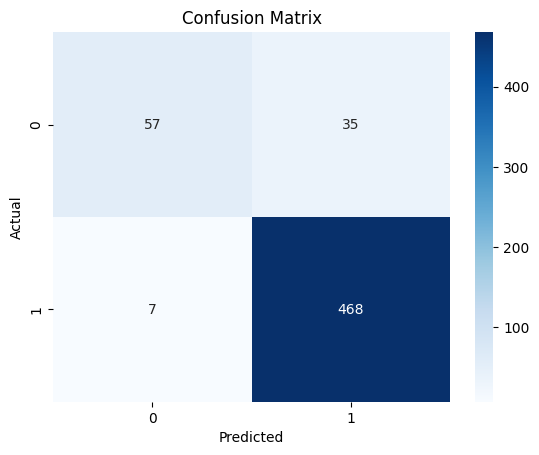

In [91]:
plot_confusion_matrix(final_model_knn)

In [92]:
# lime_plot(final_model_knn)

In [93]:
save_model(final_model_knn, best_params_knn, "knn_bioactivity_model")

Model and metadata saved to saved_model/ml_models/ChemBERTa-zinc-base-v1/


#### Ensembles

##### Voting

In [94]:
import optuna
from sklearn.ensemble import (
    VotingClassifier, 
    StackingClassifier, 
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np



# Calculate class weights
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1\n")


# ============================================================================
# 1. VOTING CLASSIFIER (Soft Voting)
# ============================================================================

print("="*70)
print("VOTING CLASSIFIER OPTIMIZATION")
print("="*70)

def objective_voting(trial):
    """
    Voting Classifier with multiple base estimators

    NOTE: to avoid multiprocessing / pickling issues (BrokenProcessPool),
    force single-threaded / no-process parallelism for estimators and the
    VotingClassifier (n_jobs=1). Also enable probability=True for SVC so
    soft voting can use predict_proba.
    """
    
    # Define base estimators with their hyperparameters
    
    # XGBoost
    # xgb_params = {
    #     'n_estimators': trial.suggest_int('xgb_n_estimators', 50, 300),
    #     'max_depth': trial.suggest_int('xgb_max_depth', 3, 10),
    #     'learning_rate': trial.suggest_float('xgb_learning_rate', 0.01, 0.3, log=True),
    #     'scale_pos_weight': scale_pos_weight,
    #     'random_state': 42,
    #     'eval_metric': 'auc',
    #     'n_jobs': 1
    # }
    
    # # LightGBM
    # lgbm_params = {
    #     'n_estimators': trial.suggest_int('lgbm_n_estimators', 50, 300),
    #     'max_depth': trial.suggest_int('lgbm_max_depth', 3, 10),
    #     'learning_rate': trial.suggest_float('lgbm_learning_rate', 0.01, 0.3, log=True),
    #     'scale_pos_weight': scale_pos_weight,
    #     'random_state': 42,
    #     'verbosity': -1,
    #     'n_jobs': 1
    # }
    
    # # Random Forest (via sklearn)
    # from sklearn.ensemble import RandomForestClassifier
    # rf_params = {
    #     'n_estimators': trial.suggest_int('rf_n_estimators', 50, 300),
    #     'max_depth': trial.suggest_int('rf_max_depth', 3, 20),
    #     'class_weight': 'balanced',
    #     'random_state': 42,
    #     'n_jobs': 1
    # }

    # # Support Vector (enable probability for soft voting)
    # sf_params={
    #     'kernel': trial.suggest_categorical('svm_kernel', ['linear', 'rbf', 'poly', 'sigmoid']),
    #     'C': trial.suggest_float('svm_C', 0.01, 10, log=True),
    #     'gamma': trial.suggest_categorical('svm_gamma', ['scale', 'auto']),
    #     'class_weight': 'balanced',
    #     'probability': True,
    #     'random_state': 42
    # }

    
    # # Logistic Regression
    # lr_params = {
    #     'C': trial.suggest_float('lr_C', 0.01, 10, log=True),
    #     'class_weight': 'balanced',
    #     'random_state': 42,
    #     'max_iter': 1000,
    #     'n_jobs': 1
    # }
    
    # Create base estimators
    estimators = [
        ('xgb', final_model_xgb),
        ('lgbm', final_model_lgbm),
        ('rf', final_model_rf),
        ('cat', final_model_cat),
        ('sf', final_model_svm),
        ('ext', final_model_et)
    ]
    
    # Voting type
    voting = trial.suggest_categorical('voting', ['soft', 'hard'])
    
    # Weights for each estimator (if soft voting)
    if voting == 'soft':
        weights = [
            trial.suggest_float(f'weight_{name}', 0.5, 2.0)
            for name in ['xgb', 'lgbm', 'rf', 'cat', 'sf', 'ext']
        ]
    else:
        weights = None
    
    # Create voting classifier
    # Set n_jobs=1 to avoid nested multiprocessing / pickling issues
    voting_model = VotingClassifier(
        estimators=estimators,
        voting=voting,
        weights=weights,
        n_jobs=1
    )
    
    voting_model.fit(X_train, y_train)
    
    if voting == 'soft':
        preds_proba = voting_model.predict_proba(X_val)[:, 1]
    else:
        # For hard voting, use predicted labels and return 1 - accuracy (same as before)
        preds = voting_model.predict(X_val)
        auc = roc_auc_score(y_val, preds)
        return 1.0 - auc
    
    auc = roc_auc_score(y_val, preds_proba)
    return 1.0 - auc

study_voting = optuna.create_study(
    direction="minimize",
    study_name="voting_optimization",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

print("Starting Voting Classifier optimization...")
study_voting.optimize(objective_voting, n_trials=50, show_progress_bar=True)

print("\n" + "="*70)
print("VOTING CLASSIFIER RESULTS")
print("="*70)
print(f"Best AUC: {1 - study_voting.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_voting.best_params.items():
    print(f"  {key}: {value}")


[I 2025-10-26 23:28:32,097] A new study created in memory with name: voting_optimization


Class imbalance ratio: 0.22:1

VOTING CLASSIFIER OPTIMIZATION
Starting Voting Classifier optimization...


Best trial: 0. Best value: 0.231151:   2%|▏         | 1/50 [00:50<41:18, 50.58s/it]

[I 2025-10-26 23:29:22,675] Trial 0 finished with value: 0.23115083232622502 and parameters: {'voting': 'hard'}. Best is trial 0 with value: 0.23115083232622502.


Best trial: 1. Best value: 0.0674827:   4%|▍         | 2/50 [01:40<40:17, 50.36s/it]

...

[I 2025-10-27 00:09:20,666] Trial 47 finished with value: 0.06286304627499906 and parameters: {'voting': 'soft', 'weight_xgb': 0.6036471922699124, 'weight_lgbm': 1.6864676813626298, 'weight_rf': 1.1815782440375724, 'weight_cat': 1.9661175084491658, 'weight_sf': 1.899716660592656, 'weight_ext': 0.5063402374400302}. Best is trial 44 with value: 0.06106974386963471.


Best trial: 44. Best value: 0.0610697:  98%|█████████▊| 49/50 [41:39<00:51, 51.35s/it]

[I 2025-10-27 00:10:12,026] Trial 48 finished with value: 0.06600132548438653 and parameters: {'voting': 'soft', 'weight_xgb': 0.7159305029248842, 'weight_lgbm': 1.5494461048253059, 'weight_rf': 0.7743845756958893, 'weight_cat': 1.7805145302514074, 'weight_sf': 1.9881069501654414, 'weight_ext': 1.997961398838929}. Best is trial 44 with value: 0.06106974386963471.


Best trial: 44. Best value: 0.0610697: 100%|██████████| 50/50 [42:31<00:00, 51.02s/it]

[I 2025-10-27 00:11:03,234] Trial 49 finished with value: 0.06223928891661146 and parameters: {'voting': 'soft', 'weight_xgb': 0.5813652204179847, 'weight_lgbm': 1.2178927353005502, 'weight_rf': 1.1759909879309747, 'weight_cat': 1.8455584309691528, 'weight_sf': 1.7566761783407991, 'weight_ext': 0.6125362273977005}. Best is trial 44 with value: 0.06106974386963471.

VOTING CLASSIFIER RESULTS
Best AUC: 0.9389

Best hyperparameters:
  voting: soft
  weight_xgb: 0.6278381080614149
  weight_lgbm: 1.6728851619424792
  weight_rf: 1.1519338072053549
  weight_cat: 1.7175910707886537
  weight_sf: 1.893955459302612
  weight_ext: 0.5914181156494868


In [100]:
estimators = [
        ('xgb', final_model_xgb),
        ('lgbm', final_model_lgbm),
        ('rf', final_model_rf),
        ('cat', final_model_cat),
        ('sf', final_model_svm),
        ('ext', final_model_et)
    ]

best_weights = [
    0.6388901135191872,  # weight_xgb
    1.9429256443254226,  # weight_lgbm
    0.8534665347331075,  # weight_rf
    0.8575437066008568,  # weight_cat
    1.8105504436658633,  # weight_sf
    0.5027142030214976   # weight_ext
]

# Create the VotingClassifier with the best parameters
voting_model = VotingClassifier(
    estimators=estimators,
    voting='soft',  # Best voting type from Optuna
    weights=best_weights,  # Best weights from Optuna
    n_jobs=1  # Avoid multiprocessing issues
)

# Fit the VotingClassifier (uses pre-trained models without retraining)
voting_model.fit(X_train, y_train)

# Predict on the validation and test sets
y_val_pred = voting_model.predict(X_val)
y_val_pred_proba = voting_model.predict_proba(X_val)[:, 1]  # Probabilities for AUC
y_test_pred = voting_model.predict(X_test)
y_test_pred_proba = voting_model.predict_proba(X_test)[:, 1]

# Calculate metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, y_val_pred_proba)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

# Detailed classification report for validation set
val_report = classification_report(y_val, y_val_pred)

In [101]:
calc_metrics(voting_model)

Accuracy: 0.9206
Balanced Acc.: 0.7817
Precision: 0.9232
Recall: 0.9874
F1 Score: 0.9542
ROC-AUC: 0.9395
MCC: 0.6804
Specificity: 0.5761
Sensitivity: 0.9874
AUPRC: 0.9851


In [97]:
calc_loss(voting_model)

Log Loss(Test): 0.22426389822799409
Log Loss(Train): 0.07656364172128807
Focal Loss (Test Set): 0.0224


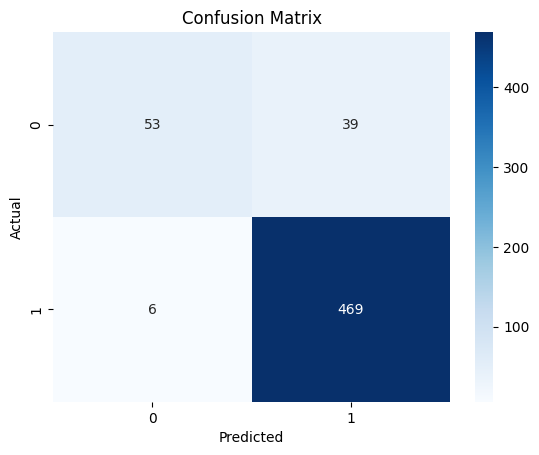

In [98]:
plot_confusion_matrix(voting_model)

In [ ]:
# lime_plot(voting_model)

KeyError: (slice(None, None, None), 0)

##### Stacking

In [102]:
import optuna
from optuna.samplers import TPESampler
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import os

# SOLUTION 1: Reduce parallelization (Recommended - Simplest)
# ============================================================================

def objective_stacking_v1(trial):
    """
    Stacking Classifier - SOLUTION 1: Use n_jobs=1 or n_jobs=2
    This is the simplest fix and often sufficient.
    """
    
    # Base estimators (Level 0)
    # xgb_params = {
    #     'n_estimators': trial.suggest_int('xgb_n_estimators', 50, 200),
    #     'max_depth': trial.suggest_int('xgb_max_depth', 3, 8),
    #     'learning_rate': trial.suggest_float('xgb_learning_rate', 0.01, 0.2, log=True),
    #     'scale_pos_weight': scale_pos_weight,
    #     'random_state': 42
    # }
    
    # lgbm_params = {
    #     'n_estimators': trial.suggest_int('lgbm_n_estimators', 50, 200),
    #     'max_depth': trial.suggest_int('lgbm_max_depth', 3, 8),
    #     'learning_rate': trial.suggest_float('lgbm_learning_rate', 0.01, 0.2, log=True),
    #     'scale_pos_weight': scale_pos_weight,
    #     'random_state': 42,
    #     'verbosity': -1
    # }
    
    # catboost_params = {
    #     'iterations': trial.suggest_int('cat_iterations', 50, 200),
    #     'depth': trial.suggest_int('cat_depth', 3, 8),
    #     'learning_rate': trial.suggest_float('cat_learning_rate', 0.01, 0.2, log=True),
    #     'scale_pos_weight': scale_pos_weight,
    #     'verbose': False,
    #     'random_state': 42
    # }

    # sf_params = {
    #     'kernel': trial.suggest_categorical('svm_kernel', ['linear', 'rbf', 'poly', 'sigmoid']),
    #     'C': trial.suggest_float('svm_C', 0.01, 10, log=True),
    #     'gamma': trial.suggest_categorical('svm_gamma', ['scale', 'auto']),
    #     'class_weight': 'balanced',
    #     'probability': True,
    #     'random_state': 42
    # }

    # rf_params = {
    #     'n_estimators': trial.suggest_int('rf_n_estimators', 50, 200),
    #     'max_depth': trial.suggest_int('rf_max_depth', 3, 15),
    #     'class_weight': 'balanced',
    #     'random_state': 42,
    #     'n_jobs': 1  # Restrict individual estimators too
    # }
    
    base_estimators = [
        ('xgb', final_model_xgb),
        ('lgbm', final_model_lgbm),
        ('catboost', final_model_cat),
        ('rf', final_model_rf),
        ('sf', final_model_svm),
        ('ext', final_model_et)
    ]
    
    # Meta-learner (Level 1)
    meta_learner_type = trial.suggest_categorical('meta_learner', ['lr', 'xgb', 'lgbm', 'cat', 'svm'])
    
    if meta_learner_type == 'lr':
        meta_penalty = trial.suggest_categorical('meta_penalty', ['l2', 'l1', 'elasticnet', 'none'])
        # Compatible solvers for each penalty
        solver_options = {
            'l2': ['lbfgs', 'liblinear', 'saga', 'newton-cg'],
            'l1': ['liblinear', 'saga'],
            'elasticnet': ['saga'],
            'none': ['lbfgs', 'newton-cg', 'saga']
        }
        meta_solver = trial.suggest_categorical('meta_solver', solver_options[meta_penalty])

        params = {
            'C': trial.suggest_float('meta_C', 0.01, 10, log=True),
            'class_weight': trial.suggest_categorical('meta_class_weight', ['balanced', None]),
            'random_state': 42,
            'max_iter': trial.suggest_int('meta_max_iter', 500, 3000, step=500),
            'solver': meta_solver,
            'penalty': meta_penalty,
            'fit_intercept': trial.suggest_categorical('meta_fit_intercept', [True, False]),
            'tol': trial.suggest_float('meta_tol', 1e-5, 1e-2, log=True),
            'n_jobs': 1  # Use -1 if safe for your environment
        }
        if meta_penalty == 'elasticnet':
            params['l1_ratio'] = trial.suggest_float('meta_l1_ratio', 0.0, 1.0)

        meta_learner = LogisticRegression(**params)
                
    elif meta_learner_type == 'xgb':
        booster = trial.suggest_categorical('meta_booster', ['gbtree', 'gblinear', 'dart'])
    
        base_params = {
            'n_estimators': trial.suggest_int('meta_n_estimators', 50, 500, step=50),
            'learning_rate': trial.suggest_float('meta_learning_rate', 0.01, 0.3, log=True),
            'reg_alpha': trial.suggest_float('meta_reg_alpha', 1e-2, 10.0, log=True),
            'reg_lambda': trial.suggest_float('meta_reg_lambda', 1e-2, 10.0, log=True),
            'scale_pos_weight': scale_pos_weight,
            'booster': booster,
            'random_state': 42,
            'n_jobs': 1,
            'eval_metric': 'auc'
        }
        
        if booster in ['gbtree', 'dart']:
            base_params.update({
                'max_depth': trial.suggest_int('meta_max_depth', 2, 10),
                'subsample': trial.suggest_float('meta_subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('meta_colsample_bytree', 0.5, 1.0),
                'gamma': trial.suggest_float('meta_gamma', 0, 5),
                'min_child_weight': trial.suggest_int('meta_min_child_weight', 1, 10),
            })
        
        if booster == 'dart':
            base_params.update({
                'rate_drop': trial.suggest_float('meta_rate_drop', 1e-3, 0.2, log=True),
                'skip_drop': trial.suggest_float('meta_skip_drop', 1e-3, 0.2, log=True)
            })
        
        meta_learner = XGBClassifier(**base_params)

    elif meta_learner_type=='lgbm':  # lgbm
        meta_learner = LGBMClassifier(
            n_estimators=trial.suggest_int('meta_n_estimators', 50, 500, step=50),
            max_depth=trial.suggest_int('meta_max_depth', 2, 12),
            num_leaves=trial.suggest_int('meta_num_leaves', 7, 128),
            learning_rate=trial.suggest_float('meta_learning_rate', 0.01, 0.3, log=True),
            subsample=trial.suggest_float('meta_subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('meta_colsample_bytree', 0.5, 1.0),
            reg_lambda=trial.suggest_float('meta_reg_lambda', 1e-2, 10.0, log=True),
            reg_alpha=trial.suggest_float('meta_reg_alpha', 1e-2, 10.0, log=True),
            min_child_samples=trial.suggest_int('meta_min_child_samples', 5, 50),
            scale_pos_weight=scale_pos_weight,
            boosting_type=trial.suggest_categorical('meta_boosting_type', ['gbdt', 'goss', 'rf']),
            min_data_in_leaf=trial.suggest_int('meta_min_data_in_leaf', 10, 100, step=10),
            random_state=42,
            verbosity=-1,
            n_jobs=1
        )

    elif meta_learner_type=='cat':
        meta_learner = CatBoostClassifier(
            iterations=trial.suggest_int('meta_iterations', 50, 500, step=50),
            depth=trial.suggest_int('meta_depth', 3, 12),
            learning_rate=trial.suggest_float('meta_learning_rate', 0.01, 0.3, log=True),
            l2_leaf_reg=trial.suggest_float('meta_l2_leaf_reg', 1, 10),
            bagging_temperature=trial.suggest_float('meta_bagging_temperature', 0, 1),
            random_strength=trial.suggest_float('meta_random_strength', 0, 2),
            border_count=trial.suggest_int('meta_border_count', 32, 255),
            scale_pos_weight=scale_pos_weight,
            boosting_type=trial.suggest_categorical('meta_boosting_type', ['Plain', 'Ordered']),
            verbose=False,
            random_state=42,
            thread_count=1  # Use 1 for compatibility in stacking
        )

    else:
        meta_learner = SVC(
            C=trial.suggest_float('meta_C', 0.01, 10, log=True),
            kernel=trial.suggest_categorical('meta_kernel', ['linear', 'rbf', 'poly']),
            gamma=trial.suggest_categorical('meta_gamma', ['scale', 'auto']),
            class_weight='balanced',
            probability=True,
            random_state=42
        )
    
    cv = StratifiedKFold(
        n_splits=trial.suggest_int('cv', 3, 5), 
        shuffle=True, 
        random_state=42
    )
    
    # KEY FIX: Use n_jobs=1 instead of n_jobs=-1
    model = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_learner,
        cv=cv,
        n_jobs=1,  # CHANGED FROM -1
        passthrough=trial.suggest_categorical('passthrough', [True, False])
    )
    
    try:
        model.fit(X_train, y_train)
        preds_proba = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, preds_proba)
        return 1.0 - auc
    except Exception as e:
        print(f"Trial failed with error: {e}")
        return 1.0  # Return worst score


# SOLUTION 3: Set Optuna to use ThreadPoolExecutor
# ============================================================================

# def run_optimization_with_threading():
#     """
#     SOLUTION 3: Configure Optuna to use threading
#     """
#     # Set environment variable
#     os.environ['OPTUNA_DISABLE_FORK'] = '1'
    
#     study = optuna.create_study(
#         direction="minimize",
#         study_name="stacking_optimization",
#         sampler=TPESampler(seed=42)
#     )
    
#     # Use executor with threading
#     study.optimize(
#         objective_stacking_v1,
#         n_trials=25,
#         show_progress_bar=True,
#         n_jobs=1  # Let Optuna handle trials sequentially
#     )
    
#     return study


# ============================================================================
# RECOMMENDED: Use this optimized version
# ============================================================================

print("\n\n" + "="*70)
print("STACKING CLASSIFIER OPTIMIZATION (FIXED)")
print("="*70)

# Set environment variable before creating study
os.environ['OPTUNA_DISABLE_FORK'] = '1'

study_stacking = optuna.create_study(
    direction="minimize",
    study_name="stacking_optimization",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

print("Starting Stacking Classifier optimization...")
study_stacking.optimize(objective_stacking_v1, n_trials=50, show_progress_bar=True)

print("\n" + "="*70)
print("STACKING CLASSIFIER RESULTS")
print("="*70)
print(f"Best AUC: {1 - study_stacking.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_stacking.best_params.items():
    print(f"  {key}: {value}")

[I 2025-10-27 01:32:39,446] A new study created in memory with name: stacking_optimization




STACKING CLASSIFIER OPTIMIZATION (FIXED)
Starting Stacking Classifier optimization...


  0%|          | 0/50 [01:28<?, ?it/s]


[W 2025-10-27 01:34:07,821] Trial 0 failed with parameters: {'meta_learner': 'xgb', 'meta_booster': 'dart', 'meta_n_estimators': 350, 'meta_learning_rate': 0.11114989443094977, 'meta_reg_alpha': 0.011527987128232402, 'meta_reg_lambda': 8.123245085588687, 'meta_max_depth': 9, 'meta_subsample': 0.6061695553391381, 'meta_colsample_bytree': 0.5909124836035503, 'meta_gamma': 0.9170225492671691, 'meta_min_child_weight': 4, 'meta_rate_drop': 0.016124278458562614, 'meta_skip_drop': 0.009860942908083906, 'cv': 3, 'passthrough': True} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "e:\ML\BioActivity\.venv\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\era\AppData\Local\Temp\ipykernel_45608\1421434647.py", line 198, in objective_stacking_v1
    model.fit(X_train, y_train)
  File "e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\ensemble\_st

KeyboardInterrupt: 

In [ ]:
# # ============================================================================
# # 3. BAGGING CLASSIFIER
# # ============================================================================

# print("\n\n" + "="*70)
# print("BAGGING CLASSIFIER OPTIMIZATION")
# print("="*70)

# def objective_bagging(trial):
#     """
#     Bagging Classifier with optimized base estimator
#     """
    
#     # Base estimator choice
#     base_estimator_type = trial.suggest_categorical('base_estimator', ['dt', 'svm', 'knn'])
    
#     if base_estimator_type == 'dt':
#         base_estimator = DecisionTreeClassifier(
#             max_depth=trial.suggest_int('dt_max_depth', 3, 20),
#             min_samples_split=trial.suggest_int('dt_min_samples_split', 2, 10),
#             min_samples_leaf=trial.suggest_int('dt_min_samples_leaf', 1, 5),
#             class_weight='balanced',
#             random_state=42
#         )
#     elif base_estimator_type == 'svm':
#         base_estimator = SVC(
#             C=trial.suggest_float('svm_C', 0.1, 10, log=True),
#             kernel=trial.suggest_categorical('svm_kernel', ['rbf', 'linear']),
#             class_weight='balanced',
#             probability=True,
#             random_state=42
#         )
#     else:  # knn
#         base_estimator = KNeighborsClassifier(
#             n_neighbors=trial.suggest_int('knn_n_neighbors', 3, 20),
#             weights=trial.suggest_categorical('knn_weights', ['uniform', 'distance']),
#             metric='minkowski'
#         )
    
#     # Bagging parameters
#     param = {
#         'estimator': base_estimator,
#         'n_estimators': trial.suggest_int('n_estimators', 10, 100),
#         'max_samples': trial.suggest_float('max_samples', 0.5, 1.0),
#         'max_features': trial.suggest_float('max_features', 0.5, 1.0),
#         'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
#         'bootstrap_features': trial.suggest_categorical('bootstrap_features', [True, False]),
#         'random_state': 42,
#         'n_jobs': -1
#     }
    
#     model = BaggingClassifier(**param)
    
#     # Use scaled data for SVM and KNN
#     if base_estimator_type in ['svm', 'knn']:
#         model.fit(X_train, y_train)
#         preds_proba = model.predict_proba(X_val)[:, 1]
#     else:
#         model.fit(X_train, y_train)
#         preds_proba = model.predict_proba(X_val)[:, 1]
    
#     auc = roc_auc_score(y_val, preds_proba)
#     return 1.0 - auc

# study_bagging = optuna.create_study(
#     direction="minimize",
#     study_name="bagging_optimization",
#     sampler=optuna.samplers.TPESampler(seed=42)
# )

# print("Starting Bagging Classifier optimization...")
# study_bagging.optimize(objective_bagging, n_trials=30, show_progress_bar=True)

# print("\n" + "="*70)
# print("BAGGING CLASSIFIER RESULTS")
# print("="*70)
# print(f"Best AUC: {1 - study_bagging.best_value:.4f}")
# print(f"\nBest hyperparameters:")
# for key, value in study_bagging.best_params.items():
#     print(f"  {key}: {value}")




In [ ]:
import optuna
from optuna.samplers import TPESampler
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import os

# ============================================================================
# 3. BAGGING CLASSIFIER (FIXED)
# ============================================================================

print("\n\n" + "="*70)
print("BAGGING CLASSIFIER OPTIMIZATION")
print("="*70)

def objective_bagging(trial):
    """
    Bagging Classifier with optimized base estimator
    FIXED: Changed n_jobs=-1 to n_jobs=1
    """
    
    # Base estimator choice
    base_estimator_type = trial.suggest_categorical('base_estimator', ['dt', 'svm', 'knn'])
    
    if base_estimator_type == 'dt':
        base_estimator = DecisionTreeClassifier(
            max_depth=trial.suggest_int('dt_max_depth', 3, 20),
            min_samples_split=trial.suggest_int('dt_min_samples_split', 2, 10),
            min_samples_leaf=trial.suggest_int('dt_min_samples_leaf', 1, 5),
            class_weight='balanced',
            random_state=42
        )
    elif base_estimator_type == 'svm':
        base_estimator = SVC(
            C=trial.suggest_float('svm_C', 0.1, 10, log=True),
            kernel=trial.suggest_categorical('svm_kernel', ['rbf', 'linear']),
            class_weight='balanced',
            probability=True,
            random_state=42
        )
    else:  # knn
        base_estimator = KNeighborsClassifier(
            n_neighbors=trial.suggest_int('knn_n_neighbors', 3, 20),
            weights=trial.suggest_categorical('knn_weights', ['uniform', 'distance']),
            metric='minkowski'
        )
    
    # Bagging parameters
    param = {
        'estimator': base_estimator,
        'n_estimators': trial.suggest_int('n_estimators', 10, 100),
        'max_samples': trial.suggest_float('max_samples', 0.5, 1.0),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'bootstrap_features': trial.suggest_categorical('bootstrap_features', [True, False]),
        'random_state': 42,
        'n_jobs': 1  # CHANGED FROM -1 (CRITICAL FIX)
    }
    
    model = BaggingClassifier(**param)
    
    try:
        # Fit the model
        model.fit(X_train, y_train)
        
        # Get predictions
        preds_proba = model.predict_proba(X_val)[:, 1]
        
        # Calculate AUC
        auc = roc_auc_score(y_val, preds_proba)
        
        return 1.0 - auc
    
    except Exception as e:
        print(f"Trial failed with error: {e}")
        return 1.0  # Return worst score on failure


# Set environment variable to prevent forking issues
os.environ['OPTUNA_DISABLE_FORK'] = '1'

# Create study
study_bagging = optuna.create_study(
    direction="minimize",
    study_name="bagging_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting Bagging Classifier optimization...")
study_bagging.optimize(objective_bagging, n_trials=30, show_progress_bar=True)

print("\n" + "="*70)
print("BAGGING CLASSIFIER RESULTS")
print("="*70)
print(f"Best AUC: {1 - study_bagging.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_bagging.best_params.items():
    print(f"  {key}: {value}")

[I 2025-10-25 01:55:02,021] A new study created in memory with name: bagging_optimization




BAGGING CLASSIFIER OPTIMIZATION
Starting Bagging Classifier optimization...


Best trial: 0. Best value: 0.0630824:   3%|▎         | 1/30 [01:51<53:54, 111.52s/it]

[I 2025-10-25 01:56:53,547] Trial 0 finished with value: 0.06308243727598561 and parameters: {'base_estimator': 'svm', 'svm_C': 1.5751320499779735, 'svm_kernel': 'rbf', 'n_estimators': 15, 'max_samples': 0.9330880728874675, 'max_features': 0.8005575058716043, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 0 with value: 0.06308243727598561.


Best trial: 0. Best value: 0.0630824:   7%|▋         | 2/30 [01:53<22:04, 47.29s/it] 

...

[I 2025-10-25 02:18:59,853] Trial 27 finished with value: 0.05604048070841239 and parameters: {'base_estimator': 'dt', 'dt_max_depth': 14, 'dt_min_samples_split': 5, 'dt_min_samples_leaf': 2, 'n_estimators': 75, 'max_samples': 0.8393171914560478, 'max_features': 0.671504675605433, 'bootstrap': False, 'bootstrap_features': True}. Best is trial 24 with value: 0.05110689437065141.


Best trial: 24. Best value: 0.0511069:  97%|█████████▋| 29/30 [57:04<10:14, 614.03s/it]

[I 2025-10-25 02:52:06,874] Trial 28 finished with value: 0.08178368121442126 and parameters: {'base_estimator': 'svm', 'svm_C': 0.18189366309739655, 'svm_kernel': 'rbf', 'n_estimators': 100, 'max_samples': 0.9437216189094652, 'max_features': 0.5962860776761355, 'bootstrap': False, 'bootstrap_features': True}. Best is trial 24 with value: 0.05110689437065141.


Best trial: 24. Best value: 0.0511069: 100%|██████████| 30/30 [57:13<00:00, 114.44s/it]

[I 2025-10-25 02:52:15,365] Trial 29 finished with value: 0.08654859793379732 and parameters: {'base_estimator': 'knn', 'knn_n_neighbors': 19, 'knn_weights': 'distance', 'n_estimators': 57, 'max_samples': 0.9203529413370048, 'max_features': 0.857131129983763, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 24 with value: 0.05110689437065141.

BAGGING CLASSIFIER RESULTS
Best AUC: 0.9489

Best hyperparameters:
  base_estimator: dt
  dt_max_depth: 18
  dt_min_samples_split: 6
  dt_min_samples_leaf: 2
  n_estimators: 84
  max_samples: 0.833651149285474
  max_features: 0.6047934968523393
  bootstrap: False
  bootstrap_features: True


In [ ]:
# ============================================================================
# 5. GRADIENT BOOSTING CLASSIFIER
# ============================================================================

print("\n\n" + "="*70)
print("GRADIENT BOOSTING CLASSIFIER OPTIMIZATION")
print("="*70)

def objective_gradientboosting(trial):
    """
    Gradient Boosting Classifier optimization
    """
    
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'loss': trial.suggest_categorical('loss', ['log_loss', 'exponential']),
        'random_state': 42
    }
    
    model = GradientBoostingClassifier(**param)
    model.fit(X_train, y_train)
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)
    
    return 1.0 - auc

study_gb = optuna.create_study(
    direction="minimize",
    study_name="gradientboosting_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting Gradient Boosting optimization...")
study_gb.optimize(objective_gradientboosting, n_trials=30, show_progress_bar=True)

print("\n" + "="*70)
print("GRADIENT BOOSTING RESULTS")
print("="*70)
print(f"Best AUC: {1 - study_gb.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_gb.best_params.items():
    print(f"  {key}: {value}")




[I 2025-10-25 02:52:15,383] A new study created in memory with name: gradientboosting_optimization




GRADIENT BOOSTING CLASSIFIER OPTIMIZATION
Starting Gradient Boosting optimization...


Best trial: 0. Best value: 0.0590133:   3%|▎         | 1/30 [00:00<00:24,  1.20it/s]

[I 2025-10-25 02:52:16,200] Trial 0 finished with value: 0.05901328273244777 and parameters: {'n_estimators': 218, 'learning_rate': 0.2536999076681772, 'max_depth': 10, 'min_samples_split': 13, 'min_samples_leaf': 2, 'subsample': 0.5779972601681014, 'max_features': 'log2', 'loss': 'log_loss'}. Best is trial 0 with value: 0.05901328273244777.


Best trial: 0. Best value: 0.0590133:   7%|▋         | 2/30 [00:02<00:36,  1.32s/it]

...

[I 2025-10-25 02:54:26,543] Trial 27 finished with value: 0.07115749525616699 and parameters: {'n_estimators': 235, 'learning_rate': 0.05103394275720652, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 5, 'subsample': 0.6614581510218185, 'max_features': 'log2', 'loss': 'log_loss'}. Best is trial 25 with value: 0.04745941387307617.


Best trial: 25. Best value: 0.0474594:  97%|█████████▋| 29/30 [02:35<00:08,  8.06s/it]

[I 2025-10-25 02:54:50,776] Trial 28 finished with value: 0.06468479865064314 and parameters: {'n_estimators': 304, 'learning_rate': 0.022649705240857215, 'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 8, 'subsample': 0.7949698813618642, 'max_features': None, 'loss': 'log_loss'}. Best is trial 25 with value: 0.04745941387307617.


Best trial: 25. Best value: 0.0474594: 100%|██████████| 30/30 [02:36<00:00,  5.22s/it]

[I 2025-10-25 02:54:52,011] Trial 29 finished with value: 0.05576639257853677 and parameters: {'n_estimators': 211, 'learning_rate': 0.0746697172628503, 'max_depth': 10, 'min_samples_split': 13, 'min_samples_leaf': 7, 'subsample': 0.5634668012615414, 'max_features': 'sqrt', 'loss': 'log_loss'}. Best is trial 25 with value: 0.04745941387307617.

GRADIENT BOOSTING RESULTS
Best AUC: 0.9525

Best hyperparameters:
  n_estimators: 304
  learning_rate: 0.07482227022847902
  max_depth: 9
  min_samples_split: 8
  min_samples_leaf: 7
  subsample: 0.6694955276426213
  max_features: sqrt
  loss: log_loss


In [ ]:
# ============================================================================
# FINAL COMPARISON OF ALL ENSEMBLE MODELS
# ============================================================================

print("\n\n" + "="*70)
print("ALL ENSEMBLE MODELS COMPARISON")
print("="*70)

ensemble_results = {
    "Voting": 1 - study_voting.best_value,
    "Stacking": 1 - study_stacking.best_value,
    "Bagging": 1 - study_bagging.best_value,
    #"AdaBoost": 1 - study_adaboost.best_value,
    "Gradient Boosting": 1 - study_gb.best_value
}

print(f"\n{'Model':<25} {'Best AUC':<10}")
print("-" * 35)
for model_name, auc in sorted(ensemble_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:<25} {auc:.4f}")

best_ensemble = max(ensemble_results.items(), key=lambda x: x[1])
print(f"\n🏆 Best Ensemble Model: {best_ensemble[0]} (AUC: {best_ensemble[1]:.4f})")

print("\n" + "="*70)
print("OPTIMIZATION COMPLETE!")
print("="*70)



ALL ENSEMBLE MODELS COMPARISON

Model                     Best AUC  
-----------------------------------
Stacking                  0.9554
Gradient Boosting         0.9525
Voting                    0.9497
Bagging                   0.9489

🏆 Best Ensemble Model: Stacking (AUC: 0.9554)

OPTIMIZATION COMPLETE!


[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerat

Tanimoto Similarity Analysis:
Mean Similarity: 0.187
Median Similarity: 0.171
Min Similarity: 0.000
Max Similarity: 1.000


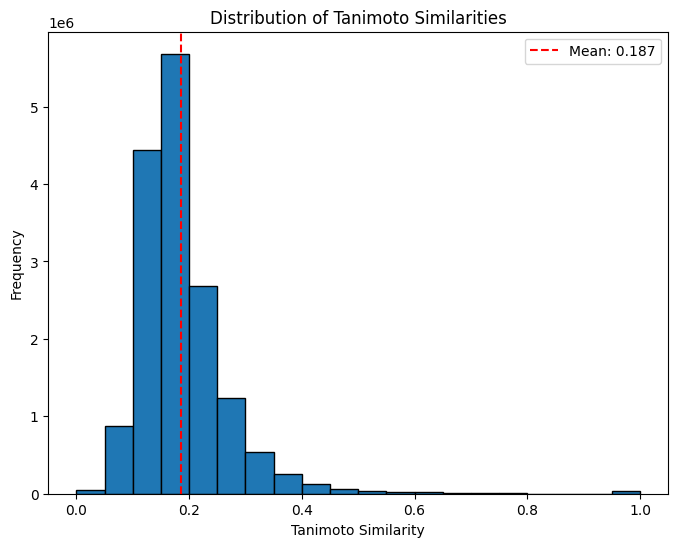


Dataset is relatively homogeneous (mean similarity: 0.187 >= 0.7 or max: 1.000 >= 0.9).
Recommendation: Use 1000 dimensions with radius 2 to avoid overfitting.


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import FingerprintSimilarity, TanimotoSimilarity
import numpy as np
import matplotlib.pyplot as plt

# Function to generate Morgan fingerprints
def generate_morgan_fp(smiles, radius=2, n_bits=1000):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)

# Example SMILES list (replace with your actual SMILES dataset)
smiles_list = features_df['canonical_smiles'].to_list()
# Generate Morgan fingerprints (using 1000D, radius 2 as a baseline)
fps = [generate_morgan_fp(smile) for smile in smiles_list]
fps = [fp for fp in fps if fp is not None]  # Filter out None values

# Calculate pairwise Tanimoto similarities
n_mols = len(fps)
similarity_matrix = np.zeros((n_mols, n_mols))
for i in range(n_mols):
    for j in range(i, n_mols):  # Only upper triangle to avoid duplicate calculations
        sim = TanimotoSimilarity(fps[i], fps[j])
        similarity_matrix[i, j] = sim
        similarity_matrix[j, i] = sim  # Symmetric matrix

# Extract unique pairwise similarities (excluding diagonal)
similarities = similarity_matrix[np.triu_indices(n_mols, k=1)]

# Statistical summary
mean_similarity = np.mean(similarities)
median_similarity = np.median(similarities)
min_similarity = np.min(similarities)
max_similarity = np.max(similarities)

print("Tanimoto Similarity Analysis:")
print(f"Mean Similarity: {mean_similarity:.3f}")
print(f"Median Similarity: {median_similarity:.3f}")
print(f"Min Similarity: {min_similarity:.3f}")
print(f"Max Similarity: {max_similarity:.3f}")

# Visualize similarity distribution
plt.figure(figsize=(8, 6))
plt.hist(similarities, bins=20, edgecolor='black')
plt.title("Distribution of Tanimoto Similarities")
plt.xlabel("Tanimoto Similarity")
plt.ylabel("Frequency")
plt.axvline(mean_similarity, color='r', linestyle='dashed', label=f'Mean: {mean_similarity:.3f}')
plt.legend()
plt.show()

# Interpretation
diversity_threshold = 0.7  # Common threshold for chemical diversity
if mean_similarity < diversity_threshold and max_similarity < 0.9:
    print(f"\nDataset is diverse (mean similarity: {mean_similarity:.3f} < {diversity_threshold}).")
    print("Recommendation: Use 2048 dimensions with radius 3 for better coverage.")
elif mean_similarity >= diversity_threshold or max_similarity >= 0.9:
    print(f"\nDataset is relatively homogeneous (mean similarity: {mean_similarity:.3f} >= {diversity_threshold} or max: {max_similarity:.3f} >= 0.9).")
    print("Recommendation: Use 1000 dimensions with radius 2 to avoid overfitting.")
else:
    print("\nDataset has moderate diversity. Test both configurations (1000D, r2 and 2048D, r3) to compare performance.")